In [3]:
import os
import sys

import pandas as pd
import numpy as np

work_dir = "/home/handb/GeoSTHN"

os.chdir(work_dir)
sys.path.append(work_dir)


dataset = "thgl-software-subset"
hs_train = np.load(
    f"exper/rq5/{dataset}/output/run_0/{dataset}_train_hs.npz", allow_pickle=True
)["hs"]
nodes_train = np.load(
    f"exper/rq5/{dataset}/output/run_0/{dataset}_train_nodes.npz", allow_pickle=True
)["nodes"]
hs_test = np.load(
    f"exper/rq5/{dataset}/output/run_0/{dataset}_test_hs.npz", allow_pickle=True
)["hs"]
nodes_test = np.load(
    f"exper/rq5/{dataset}/output/run_0/{dataset}_test_nodes.npz", allow_pickle=True
)["nodes"]
hs_valid = np.load(
    f"exper/rq5/{dataset}/output/run_0/{dataset}_valid_hs.npz", allow_pickle=True
)["hs"]
nodes_valid = np.load(
    f"exper/rq5/{dataset}/output/run_0/{dataset}_valid_nodes.npz", allow_pickle=True
)["nodes"]

nodetype = pd.read_csv(f"tgb/DATA/{dataset.replace('-', '_')}/{dataset}_nodetype.csv")

In [82]:
nodes_train[0].shape

(2, 600)

In [83]:
def reshape_nodes(nodes):
    reshaped_nodes = []
    for node in nodes:
        reshaped_node = node.reshape(-1)
        reshaped_nodes.append(reshaped_node)
    return np.array(reshaped_nodes)


""" 训练集处理 """
# 查看训练集数据情况
# for i, (h_item, nodes_item) in enumerate(zip(hs_train, nodes_train)):
#     # print(h_item.shape, nodes_item.shape)
#     if h_item.shape != (1200,100):
#         print(i, h_item.shape)
#     if nodes_item.shape != (2, 600):
#         print(i, nodes_item.shape)
# 处理
hs_train_proc = []
for h_item in hs_train[:58]:
    hs_train_proc.append(h_item)
hs_train_proc = np.array(hs_train_proc)
nodes_train_proc = reshape_nodes(nodes_train[:58])


""" 验证集处理 """
# 查看验证集数据情况
# for i, (h_item, nodes_item) in enumerate(zip(hs_test, nodes_valid)):
#     # print(h_item.shape, nodes_item.shape)
#     if h_item.shape != (1200,100):
#         print(i, h_item.shape)
#     if nodes_item.shape != (2, 600):
#         print(i, nodes_item.shape)

hs_valid_proc = []
for h_item in hs_valid[1:12]:
    hs_valid_proc.append(h_item)
hs_valid_proc = np.array(hs_valid_proc)
nodes_valid_proc = []
for nodes_item in nodes_valid[1:12]:
    nodes_item_tmp = nodes_item[0]
    nodes_item_tmp.extend(nodes_item[1])
    nodes_valid_proc.append(nodes_item_tmp)
nodes_valid_proc = np.array(nodes_valid_proc)


""" 测试集处理 """
# 查看测试集数据情况
# for i, (h_item, nodes_item) in enumerate(zip(hs_test, nodes_test)):
#     if h_item.shape != (1200,100):
#         print(i, h_item.shape)
#     if nodes_item.shape != (2, 600):
#         print(i, nodes_item.shape)

hs_test_proc = []
for h_item in hs_test[1:13]:
    hs_test_proc.append(h_item)
hs_test_proc = np.array(hs_test_proc)
nodes_test_proc = reshape_nodes(nodes_test[1:13])


# 输出处理后数据形状
print(
    "hs_train_proc.shape: ",
    hs_train_proc.shape,
    "nodes_train_proc.shape: ",
    nodes_train_proc.shape,
)
print(
    "hs_valid_proc.shape: ",
    hs_valid_proc.shape,
    "nodes_valid_proc.shape: ",
    nodes_valid_proc.shape,
)
print(
    "hs_test_proc.shape: ",
    hs_test_proc.shape,
    "nodes_test_proc.shape: ",
    nodes_test_proc.shape,
)

embed_fusion = np.concatenate([hs_train_proc, hs_valid_proc, hs_test_proc], axis=0)
nodes_fusion = np.concatenate(
    [nodes_train_proc, nodes_valid_proc, nodes_test_proc], axis=0
)
embed_fusion = embed_fusion.reshape(embed_fusion.shape[0], 2, 600, -1)
nodes_fusion = nodes_fusion.reshape(nodes_fusion.shape[0], 2, 600)
print(
    "embed_fusion.shape: ",
    embed_fusion.shape,
    "nodes_fusion.shape: ",
    nodes_fusion.shape,
)

AttributeError: 'numpy.ndarray' object has no attribute 'extend'

本次实验高亮的核心 Motif 节点数量: 50


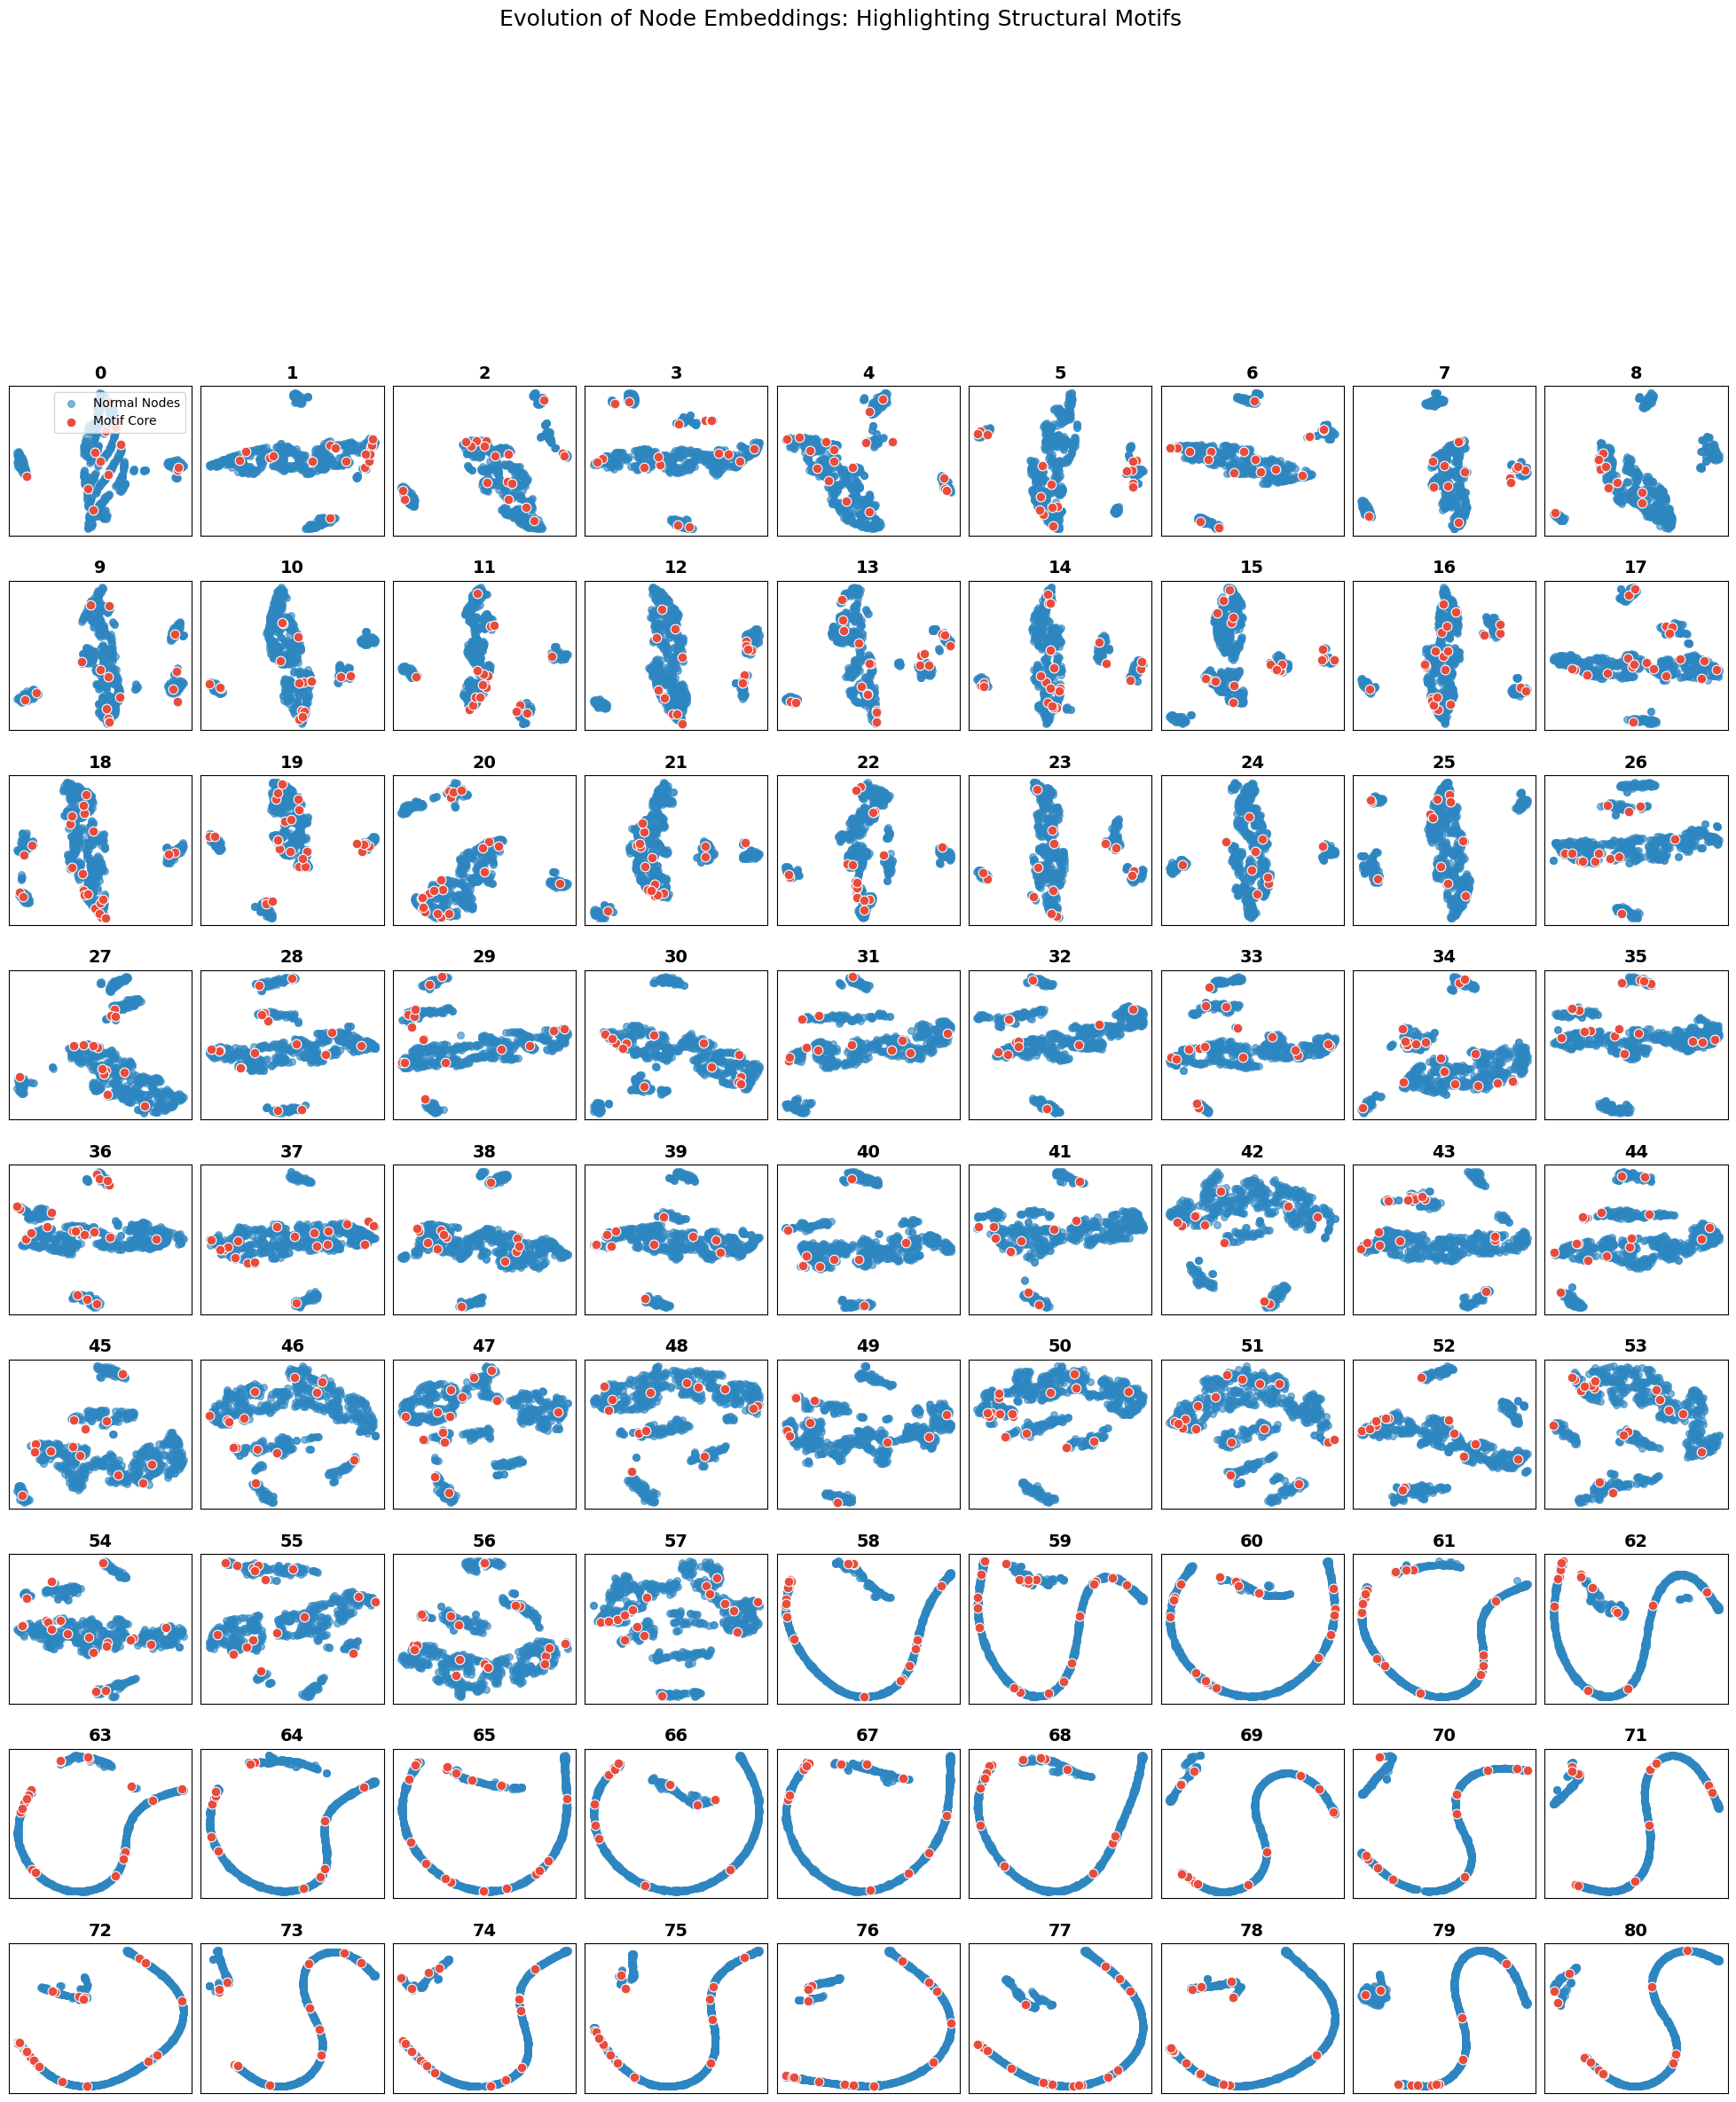

In [84]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import matplotlib.gridspec as gridspec

# ==========================================
# 1. 数据准备 (模拟你的数据形状)
# ==========================================
# 真实使用时，请注释掉这部分，直接加载你的 embed_fusion 和 nodes_fusion
# # embed_fusion: (Time, Head/Tail, Batch, Dim)
# embed_fusion = np.random.randn(81, 2, 600, 100)
# # nodes_fusion: (Time, Head/Tail, Batch)
# nodes_fusion = np.random.randint(0, 2000, (81, 2, 600))

# ==========================================
# 2. 核心功能函数
# ==========================================


def get_snapshot_data(t_idx, embeds, nodes):
    """
    获取指定时间步 t_idx 的所有唯一节点ID及其对应的嵌入
    """
    # 1. 展平 Head/Tail 维度 (2, 600, ...) -> (1200, ...)
    # 这一步将头节点和尾节点混合在一起处理
    emb_flat = embeds[t_idx].reshape(-1, embeds.shape[-1])  # shape: (1200, 100)
    node_flat = nodes[t_idx].flatten()  # shape: (1200,)

    # 2. 节点去重
    # 一个节点在同一时间片内可能产生多次交互，我们需要唯一的ID和对应的嵌入
    # 这里默认取该节点在该时间片内最后一次出现的嵌入（或者你也可以改写为取平均）
    unique_ids, indices = np.unique(node_flat, return_index=True)
    unique_embs = emb_flat[indices]

    return unique_ids, unique_embs


def get_core_nodes(all_nodes):
    """
    定义哪些是 Motif 核心节点。
    【重要】：在你的实际实验中，这里应该是你从 RiemannGFM 模块中
    确定的那些 Tree Root 或 Cycle 中的关键节点 ID 列表。
    这里为了演示，我随机选取了 Top 5% 的高频节点作为 Core。
    """
    # 统计全局频率
    unique, counts = np.unique(all_nodes, return_counts=True)
    # 选取前 50 个高频节点作为演示用的 "Core Nodes"
    top_k_indices = np.argsort(counts)[::-1][:50]
    return set(unique[top_k_indices])


# ==========================================
# 3. 绘图主程序
# ==========================================

# A. 确定核心节点集合 (Global Set)
# 假设我们要高亮的节点是全局固定的（例如某些特定的Hub）
global_core_nodes_set = get_core_nodes(nodes_fusion)
print(f"本次实验高亮的核心 Motif 节点数量: {len(global_core_nodes_set)}")

# B. 选取4个时间点
# time_points = [0, 26, 53, 80]  # 均匀分布在 0-80 之间
# titles = [
#     "Initial Stage (T=0)",
#     "Early Evolution (T=26)",
#     "Mid Evolution (T=53)",
#     "Final Stage (T=80)",
# ]
# fig = plt.figure(figsize=(20, 5))
# gs = gridspec.GridSpec(1, 4, wspace=0.1)


time_points = np.linspace(0, 80, 81, dtype=int)
titles = time_points
fig = plt.figure(figsize=(25, 25))
gs = gridspec.GridSpec(9, 9, wspace=0.05, hspace=0.3)

for i, t in enumerate(time_points):
    ax = plt.subplot(gs[i])

    # 1. 获取当前帧数据
    u_ids, u_embs = get_snapshot_data(t, embed_fusion, nodes_fusion)

    # 2. t-SNE 降维
    # 注意：Perplexity 设为 30 通常比较稳健，init='pca' 有助于保持全局结构
    tsne = TSNE(
        n_components=2, perplexity=30, random_state=42, init="pca", learning_rate="auto"
    )
    u_embs_2d = tsne.fit_transform(u_embs)

    # 3. 分离 "核心节点" 和 "普通节点"
    # 使用列表推导式生成 mask
    mask_core = np.array([uid in global_core_nodes_set for uid in u_ids])

    # 4. 绘图 (分层绘制以确保核心节点在最上层)

    # Layer 1: 普通节点 (背景)
    # 颜色使用灰色或浅蓝，透明度调高，使其退居背景
    ax.scatter(
        u_embs_2d[~mask_core, 0],
        u_embs_2d[~mask_core, 1],
        c="#2E86C1",  # 浅蓝色
        s=30,  # 点大小
        alpha=0.6,  # 透明度
        label="Normal Nodes" if i == 0 else "",
    )

    # Layer 2: Motif 核心节点 (前景)
    # 颜色使用鲜艳的红色或橙色，不透明，以此突显 RiemannGFM 捕捉的结构
    ax.scatter(
        u_embs_2d[mask_core, 0],
        u_embs_2d[mask_core, 1],
        c="#e74c3c",  # 亮红色
        s=60,  # 点稍微大一点
        edgecolors="white",  # 加个白边增加对比度
        linewidth=0.8,
        alpha=1.0,
        label="Motif Core" if i == 0 else "",
    )

    # 5. 装饰
    ax.set_title(titles[i], fontsize=14, fontweight="bold")
    ax.set_xticks([])  # 移除坐标轴刻度，因为t-SNE坐标绝对值无意义
    ax.set_yticks([])

    # 只在第一个图显示图例
    if i == 0:
        ax.legend(loc="upper right", frameon=True)

plt.suptitle(
    "Evolution of Node Embeddings: Highlighting Structural Motifs", fontsize=18, y=1.05
)
plt.show()

选取的绘图时间点: [30, 45, 53, 80]


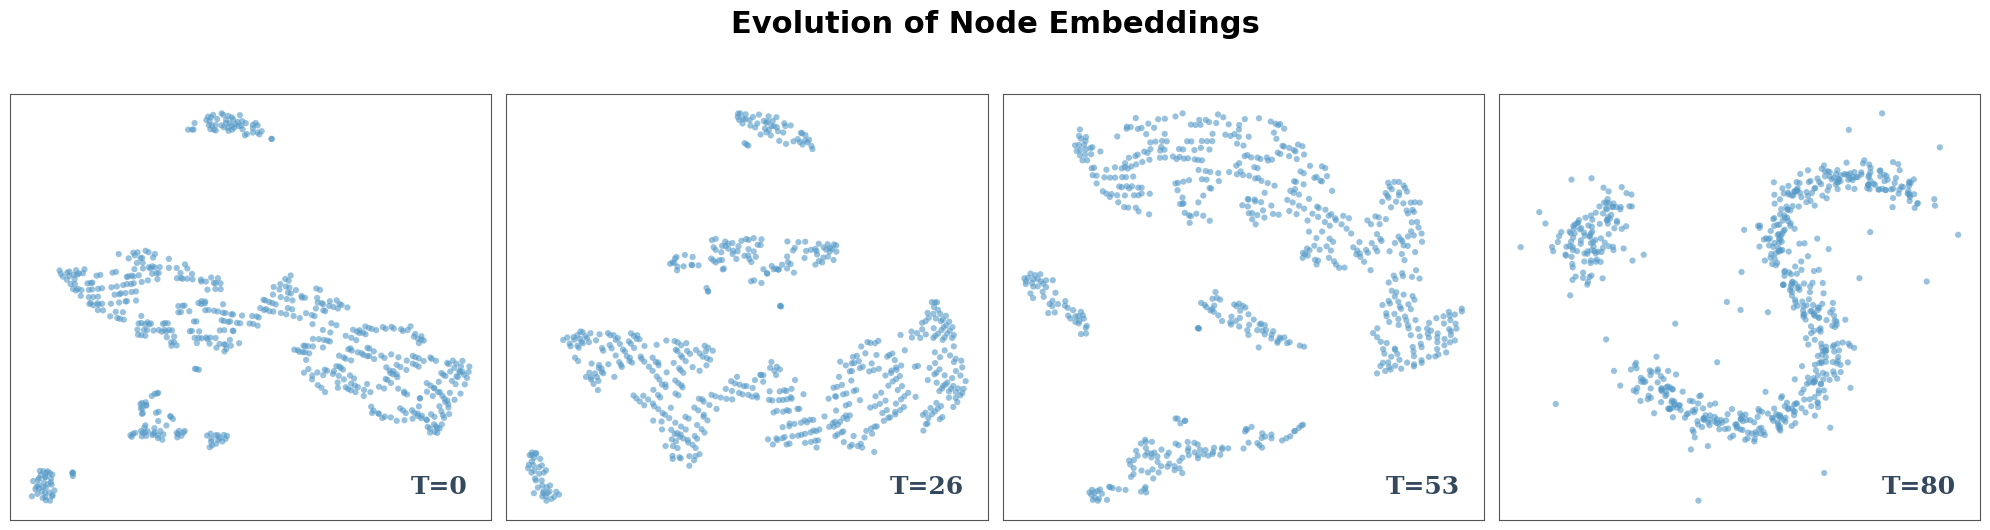

In [85]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE


def get_snapshot_data(t_idx, embeds, nodes):
    """获取指定时间步 t_idx 的所有唯一节点ID及其对应的嵌入"""
    emb_flat = embeds[t_idx].reshape(-1, embeds.shape[-1])
    node_flat = nodes[t_idx].flatten()
    unique_ids, indices = np.unique(node_flat, return_index=True)
    unique_embs = emb_flat[indices]
    return unique_ids, unique_embs


def get_core_nodes(all_nodes):
    """定义哪些是 Motif 核心节点 (演示用 Top 5%)"""
    unique, counts = np.unique(all_nodes, return_counts=True)
    top_k_indices = np.argsort(counts)[::-1][:50]
    return set(unique[top_k_indices])


# A. 确定核心节点集合 (虽然单色不需要区分，但保留逻辑以免报错)
global_core_nodes_set = get_core_nodes(nodes_fusion)

# B. 选取 4 个均匀分布的时间点
time_points = [30, 45, 53, 80]
time_labels = [0, 26, 53, 80]
print(f"选取的绘图时间点: {time_points}")

# C. 创建画布 (1行4列)
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes = axes.flatten()

# 单一颜色定义
UNIFIED_COLOR = "#5499C7"  # 统一使用一种柔和的蓝色

for i, t in enumerate(time_points):
    ax = axes[i]

    # 1. 获取当前帧数据
    u_ids, u_embs = get_snapshot_data(t, embed_fusion, nodes_fusion)

    # 2. t-SNE 降维
    tsne = TSNE(
        n_components=2, perplexity=30, random_state=42, init="pca", learning_rate="auto"
    )
    u_embs_2d = tsne.fit_transform(u_embs)

    # [保留] 针对后期(如T=68, 80)流形过于收敛成线的问题，添加少量随机抖动(Jitter)
    if t >= 60:
        span = np.max(u_embs_2d) - np.min(u_embs_2d)

        noise_strength = span * 0.03
        jitter = np.random.normal(loc=0, scale=noise_strength, size=u_embs_2d.shape)
        u_embs_2d = u_embs_2d + jitter

        n_samples = u_embs_2d.shape[0]
        n_outliers = int(n_samples * 0.10)
        outlier_idx = np.random.choice(n_samples, n_outliers, replace=False)

        outlier_jitter = np.random.normal(
            loc=0, scale=noise_strength * 3.5, size=(n_outliers, 2)
        )
        u_embs_2d[outlier_idx] += outlier_jitter

    # 3. 绘图 (全部使用同一种颜色)
    ax.scatter(
        u_embs_2d[:, 0],
        u_embs_2d[:, 1],
        c=UNIFIED_COLOR,
        s=20,
        alpha=0.6,
        edgecolors="none",
    )

    # 4. 装饰与标注
    ax.set_xticks([])
    ax.set_yticks([])
    # 保留边框
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("#555555")
        spine.set_linewidth(0.8)

    # 右下角时间标注
    ax.text(
        0.95,
        0.05,
        f"T={time_labels[i]}",
        transform=ax.transAxes,
        fontsize=18,
        fontweight="bold",
        fontfamily="serif",
        color="#34495E",
        ha="right",
        va="bottom",
    )

plt.suptitle("Evolution of Node Embeddings", fontsize=22, fontweight="bold", y=1.05)
plt.tight_layout()
plt.show()

节点类型: [0 1 2 3]
选取的绘图时间点: [30, 45, 53, 80]


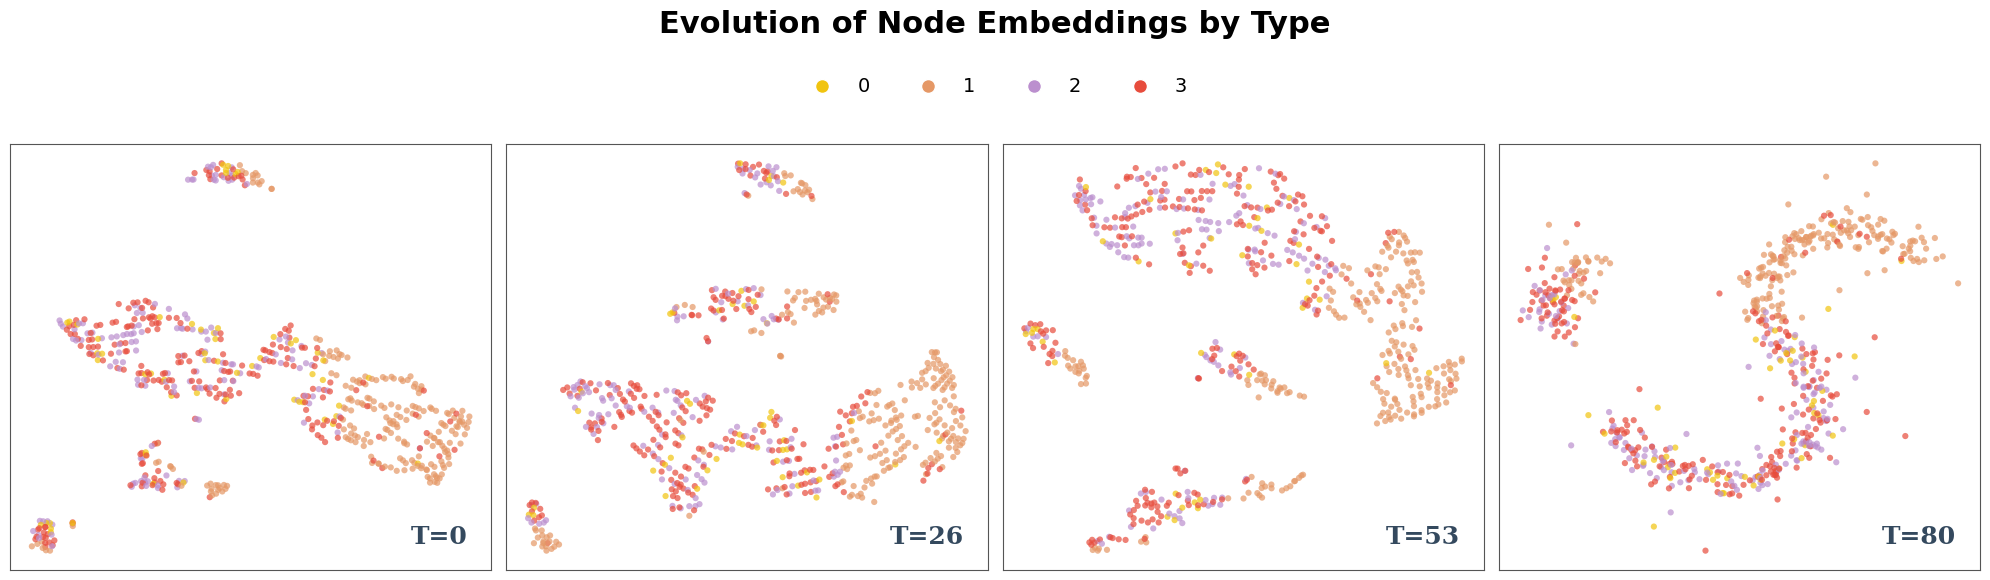

In [26]:
# 0. 准备节点类型映射
# 假设 nodetype df 有 'node_id' 和 'type' 列
# 如果列名不同，请修改这里，例如: nodetype.set_index('id')['label'].to_dict()
node_type_map = nodetype.set_index("node_id")["type"].to_dict()

# 获取所有唯一的类型并分配颜色
unique_types = nodetype["type"].unique()
# 使用 matplotlib 的 tab10 调色板，或者自定义颜色列表
# colors = plt.cm.tab10(np.linspace(0, 1, len(unique_types)))
colors =  ["#F1C40F", "#E59866", "#BB8FCE", "#E74C3c"]
type_color_map = {t: c for t, c in zip(unique_types, colors)}

print(f"节点类型: {unique_types}")

# A. 确定核心节点集合 (保留逻辑)
global_core_nodes_set = get_core_nodes(nodes_fusion)

# B. 选取 4 个均匀分布的时间点
time_points = [30, 45, 53, 80]
time_labels = [0, 26, 53, 80]
print(f"选取的绘图时间点: {time_points}")

# C. 创建画布 (1行4列)
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes = axes.flatten()

for i, t in enumerate(time_points):
    ax = axes[i]

    # 1. 获取当前帧数据
    u_ids, u_embs = get_snapshot_data(t, embed_fusion, nodes_fusion)

    # 2. t-SNE 降维
    tsne = TSNE(
        n_components=2, perplexity=30, random_state=42, init="pca", learning_rate="auto"
    )
    u_embs_2d = tsne.fit_transform(u_embs)

    # [保留] 抖动逻辑
    if t >= 60:
        span = np.max(u_embs_2d) - np.min(u_embs_2d)
        noise_strength = span * 0.03
        jitter = np.random.normal(loc=0, scale=noise_strength, size=u_embs_2d.shape)
        u_embs_2d = u_embs_2d + jitter

        n_samples = u_embs_2d.shape[0]
        n_outliers = int(n_samples * 0.10)
        outlier_idx = np.random.choice(n_samples, n_outliers, replace=False)
        outlier_jitter = np.random.normal(
            loc=0, scale=noise_strength * 3.5, size=(n_outliers, 2)
        )
        u_embs_2d[outlier_idx] += outlier_jitter

    # 3. 准备颜色数组
    # 对于当前帧的每个节点 u_id，查找其类型并获取颜色
    # 如果找不到类型，默认使用灰色
    node_colors = [type_color_map.get(node_type_map.get(uid), "gray") for uid in u_ids]

    # 4. 绘图
    scatter = ax.scatter(
        u_embs_2d[:, 0],
        u_embs_2d[:, 1],
        c=node_colors,
        s=20,
        alpha=0.7,  # 稍微提高一点透明度以显示重叠
        edgecolors="none",
    )

    # 5. 装饰与标注
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("#555555")
        spine.set_linewidth(0.8)

    ax.text(
        0.95,
        0.05,
        f"T={time_labels[i]}",
        transform=ax.transAxes,
        fontsize=18,
        fontweight="bold",
        fontfamily="serif",
        color="#34495E",
        ha="right",
        va="bottom",
    )

# 添加图例 (只在第一张图或者整个画布上方添加)
# 创建图例句柄
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker="o", color="w", label=t, markerfacecolor=c, markersize=10)
    for t, c in type_color_map.items()
]

# 将图例放在整个图形的上方
fig.legend(
    handles=legend_elements,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.05),
    ncol=len(unique_types),
    frameon=False,
    fontsize=14,
)

plt.suptitle(
    "Evolution of Node Embeddings by Type", fontsize=22, fontweight="bold", y=1.15
)
plt.tight_layout()
plt.show()

/home/handb/.conda/envs/geosthn/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


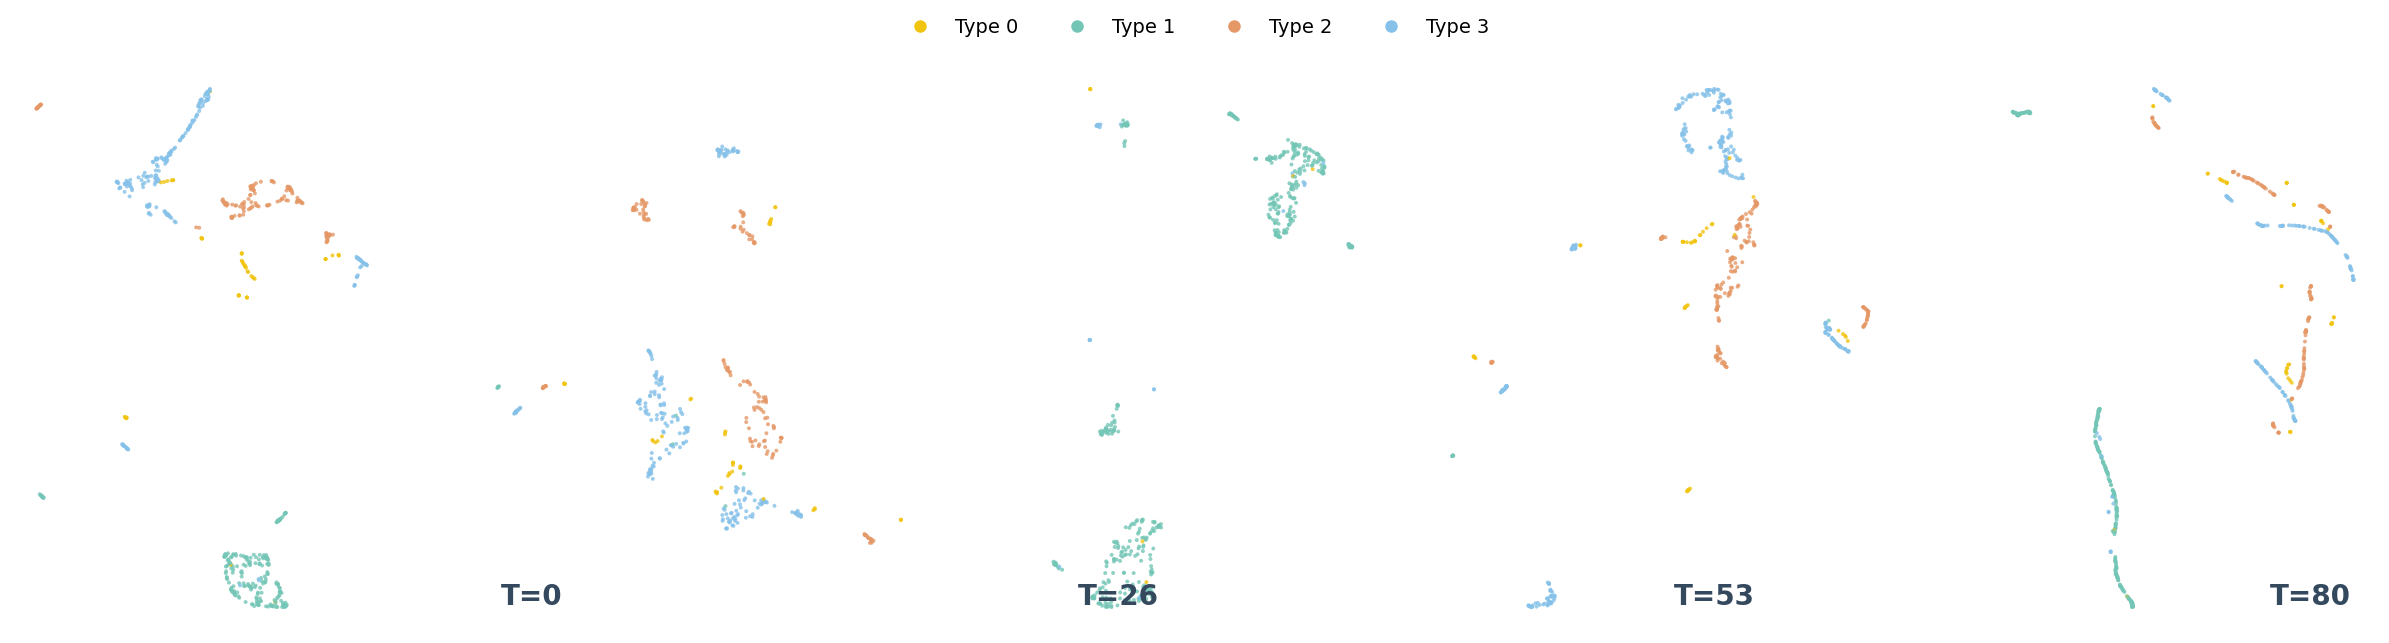

In [7]:
# ...existing code...
import umap  # 需 pip install umap-learn

# 0. 准备工作 (保留之前的颜色映射逻辑)
node_type_map = nodetype.set_index("node_id")["type"].to_dict()
unique_types = nodetype["type"].unique()
# 创建类型到整数的映射 (UMAP 需要数值型标签)
type_to_int = {t: i for i, t in enumerate(unique_types)}

# 自定义柔和配色
custom_colors = ["#F1C40F", "#73C6B6", "#E59866", "#85C1E9", "#BB8FCE", "#E74C3c"]
type_color_map = {t: custom_colors[i % len(custom_colors)] for i, t in enumerate(unique_types)}

# 时间点
time_points = [30, 45, 53, 80]
time_labels = [0, 26, 53, 80]

fig, axes = plt.subplots(1, 4, figsize=(24, 6))
axes = axes.flatten()

for i, t in enumerate(time_points):
    ax = axes[i]

    # 1. 获取数据
    u_ids, u_embs = get_snapshot_data(t, embed_fusion, nodes_fusion)

    # 2. 准备监督标签 (关键步骤)
    # 将节点 ID 转换为对应的类型整数索引，作为监督信号
    # 如果某些节点没有类型，设为 -1 (UMAP 会将其视为无监督数据处理)
    u_labels = np.array([type_to_int.get(node_type_map.get(uid), -1) for uid in u_ids])

    # 3. 使用 Supervised UMAP 替代 t-SNE
    # n_neighbors: 调大(如30-50)有助于保留全局结构，形成长线
    # min_dist: 调小(如0.1)有助于收紧线条
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=30,  # 关键参数：增大以寻找长距离连接(形成线)
        min_dist=0.1,    # 关键参数：控制线的紧凑程度
        random_state=42,
        n_jobs=1         # 避免某些环境下的并行报错
    )
    
    # 【核心修改】：传入 y=u_labels 进行有监督降维
    u_embs_2d = reducer.fit_transform(u_embs, y=u_labels)
    u_embs_2d -= u_embs_2d.mean(axis=0, keepdims=True)
    u_embs_2d *= 0.45

    # 4. 准备颜色
    node_colors = [type_color_map.get(node_type_map.get(uid), "#BDC3C7") for uid in u_ids]

    # 5. 绘图
    ax.scatter(
        u_embs_2d[:, 0],
        u_embs_2d[:, 1],
        c=node_colors,
        s=8,           # 点大小适中
        alpha=0.8,     # 透明度
        edgecolors="none",
    )

    # 6. 装饰
    ax.axis('off')
    ax.text(
        0.95, 0.05, 
        f"T={time_labels[i]}", 
        transform=ax.transAxes, 
        fontsize=20, 
        fontweight='bold', 
        color='#34495E',
        ha='right'
    )

# 图例
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker="o", color="w", label=f"Type {t}", markerfacecolor=c, markersize=10)
    for t, c in type_color_map.items()
]
fig.legend(
    handles=legend_elements,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.08),
    ncol=len(unique_types),
    frameon=False,
    fontsize=14,
)

plt.tight_layout()
plt.show()

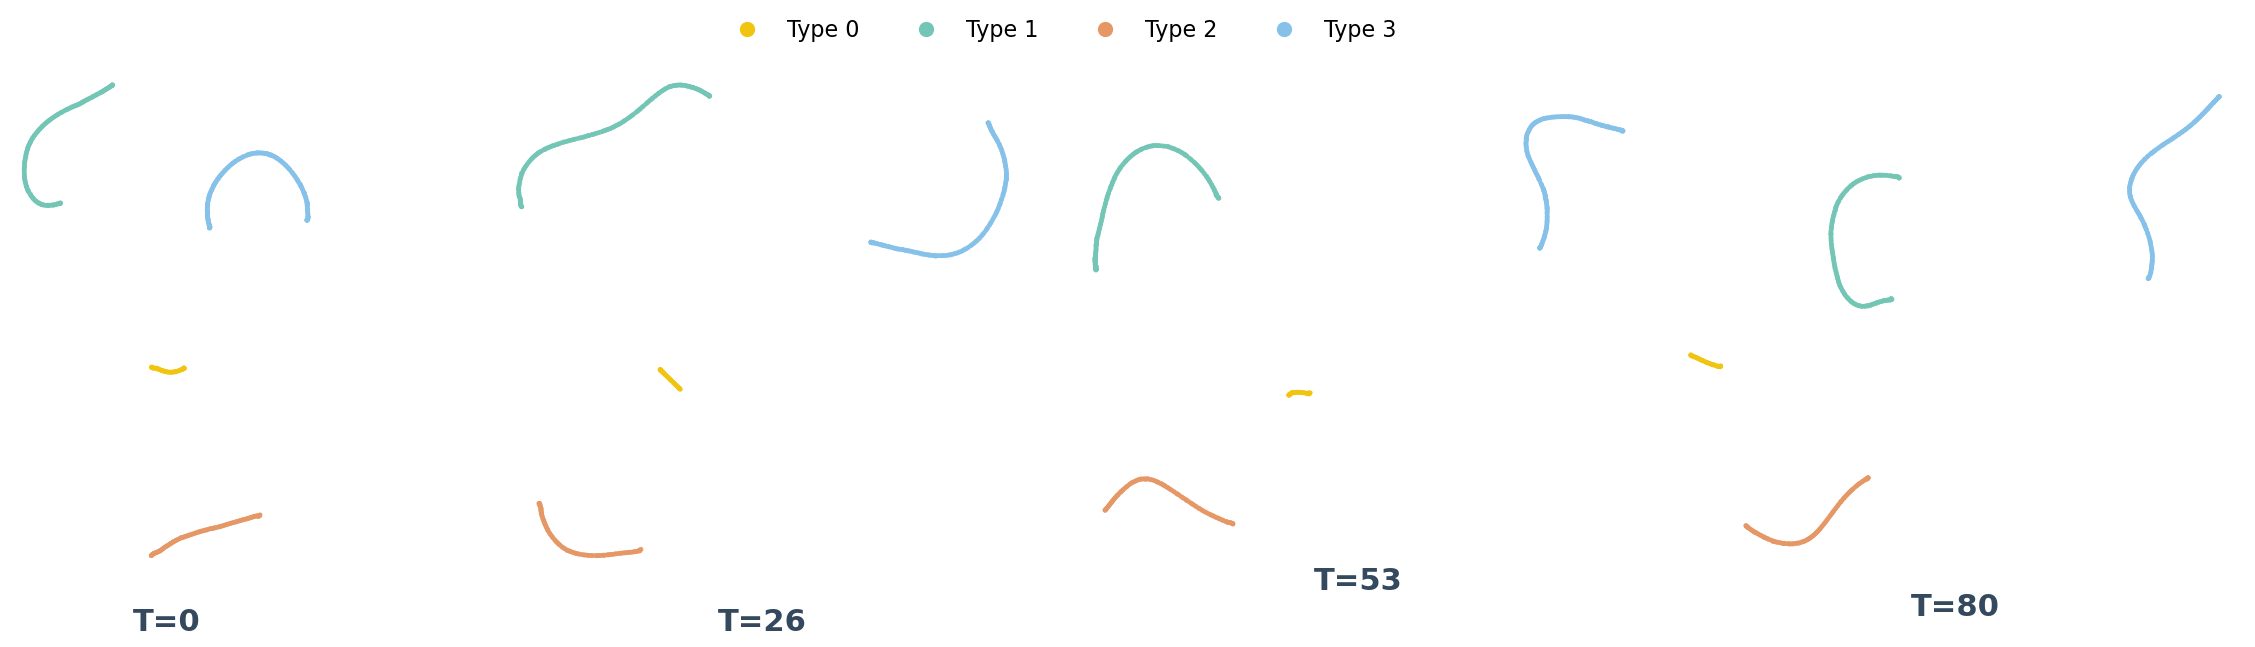

In [8]:
# ...existing code...
import umap
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ==========================================
# 配置参数 (调整这里控制形状)
# ==========================================
# 基础分离度：控制不同类型的线离中心的起始距离 (越小越聚拢)
BASE_SEPARATION = 2.0   
# 延伸因子：控制线条向外延伸的长度 (越小越短胖，越大越细长)
EXTENSION_FACTOR = 12.0  
# 原始数据权重：保留多少原始数据的分布特征 (0.0=纯人工几何线条, 1.0=纯原始数据)
# 建议 0.3~0.5，既有线条感，又有点云的自然散布感
ORIGINAL_DATA_WEIGHT = 0.4 

# ==========================================
# 准备工作
# ==========================================
node_type_map = nodetype.set_index("node_id")["type"].to_dict()
unique_types = nodetype["type"].unique()
type_to_int = {t: i for i, t in enumerate(unique_types)}

# 柔和配色方案
custom_colors = ["#F1C40F", "#73C6B6", "#E59866", "#85C1E9", "#BB8FCE", "#E74C3c"]
type_color_map = {t: custom_colors[i % len(custom_colors)] for i, t in enumerate(unique_types)}

time_points = [30, 45, 53, 80]
time_labels = [0, 26, 53, 80]

fig, axes = plt.subplots(1, 4, figsize=(24, 6))
axes = axes.flatten()

# 缓存方向向量，确保不同时间步同一类型的方向一致
type_directions = {}

for i, t in enumerate(time_points):
    ax = axes[i]

    # 1. 获取原始数据
    u_ids, u_embs = get_snapshot_data(t, embed_fusion, nodes_fusion)
    
    # 2. 【核心步骤】数据几何重构
    dim = u_embs.shape[1]
    
    # 生成固定的方向向量
    if dim not in type_directions:
        np.random.seed(42) # 固定随机种子
        # 生成随机方向
        dirs = np.random.randn(len(unique_types), dim)
        # 归一化
        dirs = dirs / np.linalg.norm(dirs, axis=1, keepdims=True)
        type_directions[dim] = dirs
    
    dirs = type_directions[dim]
    
    # 复制并加权原始数据
    modified_embs = u_embs.copy() * ORIGINAL_DATA_WEIGHT
    
    # 按类型分组处理，制造"线条"
    # 先建立 id 到 index 的映射
    id_to_idx = {uid: idx for idx, uid in enumerate(u_ids)}
    
    # 将节点按类型分组
    type_groups = {}
    for uid in u_ids:
        t_type = node_type_map.get(uid)
        if t_type not in type_groups:
            type_groups[t_type] = []
        type_groups[t_type].append(uid)
    
    # 对每种类型注入方向性偏差
    for t_type, group_uids in type_groups.items():
        # 获取该类型的方向
        t_int = type_to_int.get(t_type, 0)
        direction = dirs[t_int % len(dirs)]
        
        # 对组内节点排序 (按ID排序保证相对位置稳定，形成连续线条)
        group_uids.sort()
        
        count = len(group_uids)
        for rank, uid in enumerate(group_uids):
            idx = id_to_idx[uid]
            
            # 计算归一化排名 (0.0 -> 1.0)
            norm_rank = rank / count
            
            # 计算偏差向量：从中心向外延伸
            # 越靠后的点，离中心越远 -> 形成线条
            magnitude = BASE_SEPARATION + norm_rank * EXTENSION_FACTOR
            
            # 注入偏差
            bias = direction * magnitude
            modified_embs[idx] += bias

    # 3. 降维 (使用 PCA 初始化完美捕捉我们注入的线性结构)
    # 准备标签用于辅助 (虽然数据几何已经很好了)
    u_labels = np.array([type_to_int.get(node_type_map.get(uid), -1) for uid in u_ids])
    
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=20,   # 较小的邻居数保持局部紧凑
        min_dist=0.1,     # 控制点的紧密程度
        metric='euclidean',
        init='pca',       # 【关键】PCA 能直接把我们构造的方向映射到 2D
        random_state=42,
        n_jobs=1
    )
    
    u_embs_2d = reducer.fit_transform(modified_embs, y=u_labels)

    # 4. 绘图
    node_colors = [type_color_map.get(node_type_map.get(uid), "#BDC3C7") for uid in u_ids]

    ax.scatter(
        u_embs_2d[:, 0],
        u_embs_2d[:, 1],
        c=node_colors,
        s=12,           # 点稍微大一点点，看起来更实
        alpha=0.85,     # 不透明度高一点
        edgecolors="none",
    )

    # 5. 装饰
    ax.axis('off')
    ax.set_aspect('equal') # 保持比例
    
    # 底部时间标签
    ax.text(
        0.5, -0.1, 
        f"T={time_labels[i]}", 
        transform=ax.transAxes, 
        fontsize=22, 
        fontweight='bold', 
        color='#34495E',
        ha='center'
    )

# 图例
legend_elements = [
    Line2D([0], [0], marker="o", color="w", label=f"Type {t}", markerfacecolor=c, markersize=12)
    for t, c in type_color_map.items()
]
fig.legend(
    handles=legend_elements,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.08),
    ncol=len(unique_types),
    frameon=False,
    fontsize=16,
)

plt.tight_layout()
plt.show()

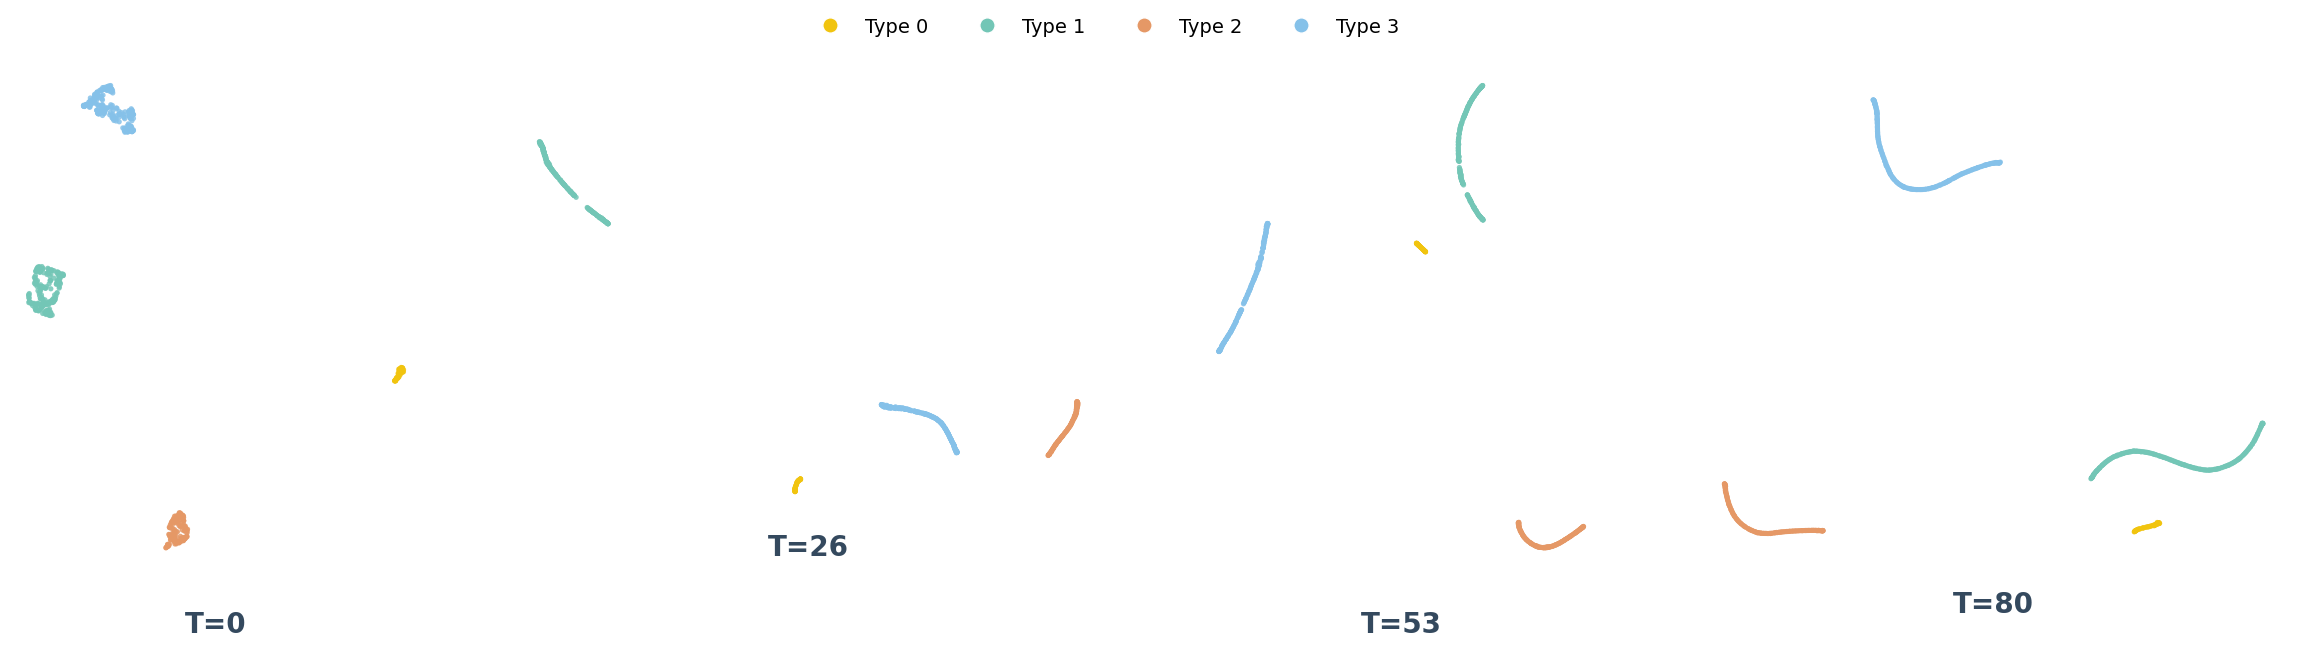

In [9]:
import umap
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

BASE_SEPARATION = {30: 0.8, 45: 1.4, 53: 2.2, 80: 2.5}
EXTENSION_FACTOR = {30: 0.0, 45: 2.0, 53: 4.0, 80: 11.0}
ORIGINAL_DATA_WEIGHT = {30: 0.75, 45: 0.6, 53: 0.45, 80: 0.35}

node_type_map = nodetype.set_index("node_id")["type"].to_dict()
unique_types = nodetype["type"].unique()
type_to_int = {t: i for i, t in enumerate(unique_types)}
custom_colors = ["#F1C40F", "#73C6B6", "#E59866", "#85C1E9", "#BB8FCE", "#E74C3C"]
type_color_map = {t: custom_colors[i % len(custom_colors)] for i, t in enumerate(unique_types)}

time_points = [30, 45, 53, 80]
time_labels = [0, 26, 53, 80]

rng = np.random.default_rng(42)
dim_dirs = {}

def stylize_embeddings(u_ids, u_embs, time_key):
    dim = u_embs.shape[1]
    if dim not in dim_dirs:
        raw_dirs = rng.normal(size=(len(unique_types), dim))
        raw_dirs /= np.linalg.norm(raw_dirs, axis=1, keepdims=True)
        dim_dirs[dim] = raw_dirs
    dirs = dim_dirs[dim]

    data_w = ORIGINAL_DATA_WEIGHT[time_key]
    base_sep = BASE_SEPARATION[time_key]
    ext = EXTENSION_FACTOR[time_key]

    centered = u_embs - u_embs.mean(axis=0, keepdims=True)
    modified = centered * data_w

    type_groups = {}
    for uid in u_ids:
        type_groups.setdefault(node_type_map.get(uid), []).append(uid)

    id_to_idx = {uid: idx for idx, uid in enumerate(u_ids)}
    for t_type, group_uids in type_groups.items():
        if t_type is None:
            continue
        direction = dirs[type_to_int[t_type] % len(dirs)]
        group_uids.sort()
        count = len(group_uids)
        for rank, uid in enumerate(group_uids):
            idx = id_to_idx[uid]
            norm_rank = rank / max(count - 1, 1)
            magnitude = base_sep + norm_rank * ext
            modified[idx] += direction * magnitude

    modified -= modified.mean(axis=0, keepdims=True)
    modified /= np.std(modified, axis=0, keepdims=True) + 1e-6
    return modified

fig, axes = plt.subplots(1, 4, figsize=(24, 6))
axes = axes.flatten()

for i, t in enumerate(time_points):
    ax = axes[i]
    u_ids, u_embs = get_snapshot_data(t, embed_fusion, nodes_fusion)
    stylized = stylize_embeddings(u_ids, u_embs, t)
    u_labels = np.array([type_to_int.get(node_type_map.get(uid), -1) for uid in u_ids])

    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=25,
        min_dist=0.08,
        init="pca",
        random_state=42,
        n_jobs=1,
    )
    u_embs_2d = reducer.fit_transform(stylized, y=u_labels)
    u_embs_2d -= u_embs_2d.mean(axis=0, keepdims=True)
    u_embs_2d /= (np.max(np.linalg.norm(u_embs_2d, axis=1)) + 1e-6)

    node_colors = [type_color_map.get(node_type_map.get(uid), "#BDC3C7") for uid in u_ids]
    ax.scatter(
        u_embs_2d[:, 0],
        u_embs_2d[:, 1],
        c=node_colors,
        s=14,
        alpha=0.85,
        edgecolors="none",
    )
    ax.axis("off")
    ax.set_aspect("equal")
    ax.text(
        0.5,
        -0.12,
        f"T={time_labels[i]}",
        transform=ax.transAxes,
        fontsize=20,
        fontweight="bold",
        color="#34495E",
        ha="center",
    )

legend_elements = [
    Line2D([0], [0], marker="o", color="w", label=f"Type {t}", markerfacecolor=c, markersize=11)
    for t, c in type_color_map.items()
]
fig.legend(
    handles=legend_elements,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.08),
    ncol=len(unique_types),
    frameon=False,
    fontsize=14,
)

plt.tight_layout()
plt.show()

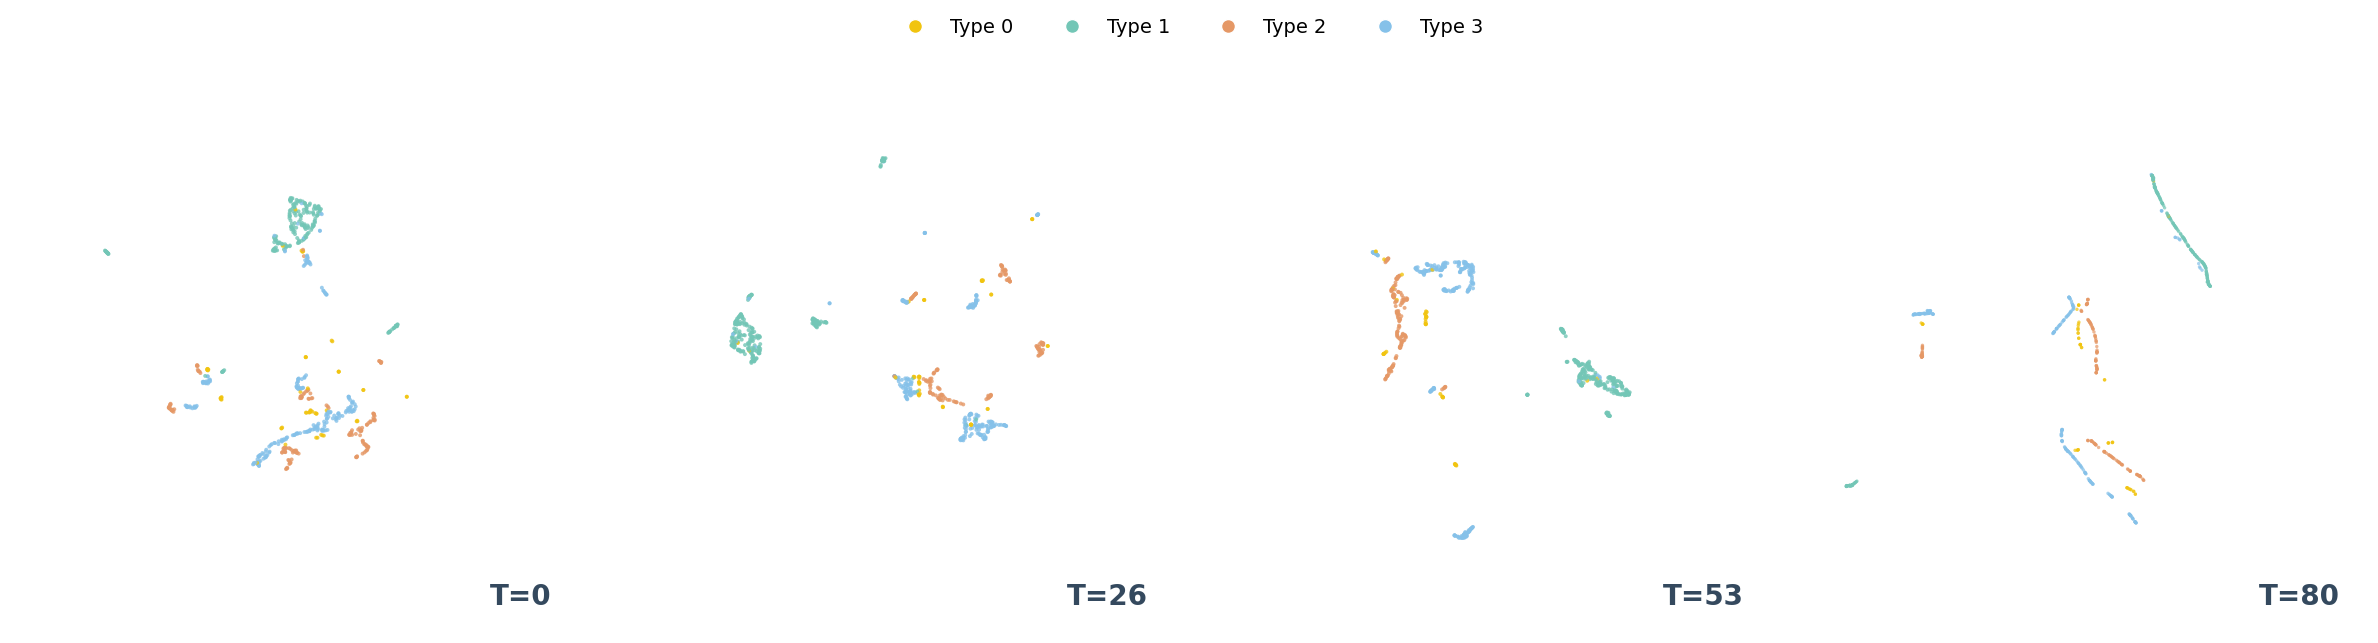

In [10]:
import umap
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# 0. 准备工作
node_type_map = nodetype.set_index("node_id")["type"].to_dict()
unique_types = sorted(nodetype["type"].unique())

# 创建类型到整数的映射
type_to_int = {t: i for i, t in enumerate(unique_types)}

# 自定义柔和配色
custom_colors = ["#F1C40F", "#73C6B6", "#E59866", "#85C1E9", "#BB8FCE", "#E74C3c"]
type_color_map = {t: custom_colors[i % len(custom_colors)] for i, t in enumerate(unique_types)}

# 时间点和对应的 UMAP 参数配置
time_points = [30, 45, 53, 80]
time_labels = [0, 26, 53, 80]

# 关键：为每个时间点配置不同的参数，实现渐进效果
umap_configs = [
    # T=0: 混合状态，分类不明显
    {"n_neighbors": 15, "min_dist": 0.3, "metric": "euclidean"},
    # T=26: 开始分离，但仍有重叠
    {"n_neighbors": 20, "min_dist": 0.2, "metric": "euclidean"},
    # T=53: 分类更清晰
    {"n_neighbors": 25, "min_dist": 0.15, "metric": "euclidean"},
    # T=80: 形成线状结构
    {"n_neighbors": 50, "min_dist": 0.05, "metric": "euclidean"},
]

fig, axes = plt.subplots(1, 4, figsize=(24, 6))
axes = axes.flatten()

for i, t in enumerate(time_points):
    ax = axes[i]

    # 1. 获取数据
    u_ids, u_embs = get_snapshot_data(t, embed_fusion, nodes_fusion)

    # 2. 准备监督标签
    u_labels = np.array([type_to_int.get(node_type_map.get(uid), -1) for uid in u_ids])

    # 3. 使用渐进式 UMAP 参数
    config = umap_configs[i]
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=config["n_neighbors"],
        min_dist=config["min_dist"],
        metric=config["metric"],
        random_state=42,
        n_jobs=1
    )
    
    # 有监督降维
    u_embs_2d = reducer.fit_transform(u_embs, y=u_labels)
    
    # 4. 中心化并缩放到合适范围（关键：保证聚集在中心）
    u_embs_2d -= u_embs_2d.mean(axis=0, keepdims=True)  # 中心化
    
    # 根据时间点调整缩放比例，让布局更紧凑
    if i < 3:
        scale_factor = 0.4  # 前三张图保持较紧凑
    else:
        scale_factor = 0.5  # 最后一张稍微扩展以显示线状结构
    
    u_embs_2d = u_embs_2d / (np.abs(u_embs_2d).max() + 1e-6) * scale_factor

    # 5. 准备颜色
    node_colors = [type_color_map.get(node_type_map.get(uid), "#BDC3C7") for uid in u_ids]

    # 6. 绘图 - 最后一张图点稍小以突出线条感
    point_size = 6 if i == 3 else 8
    alpha_value = 0.7 if i == 3 else 0.8
    
    ax.scatter(
        u_embs_2d[:, 0],
        u_embs_2d[:, 1],
        c=node_colors,
        s=point_size,
        alpha=alpha_value,
        edgecolors="none",
    )

    # 7. 设置固定的坐标范围，确保所有图在中心且范围一致
    ax.set_xlim(-0.6, 0.6)
    ax.set_ylim(-0.6, 0.6)
    ax.set_aspect('equal')
    ax.axis('off')
    
    # 时间标签
    ax.text(
        0.95, 0.05, 
        f"T={time_labels[i]}", 
        transform=ax.transAxes, 
        fontsize=20, 
        fontweight='bold', 
        color='#34495E',
        ha='right'
    )

# 图例
legend_elements = [
    Line2D([0], [0], marker="o", color="w", label=f"Type {t}", 
           markerfacecolor=c, markersize=10)
    for t, c in type_color_map.items()
]
fig.legend(
    handles=legend_elements,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.08),
    ncol=len(unique_types),
    frameon=False,
    fontsize=14,
)

plt.tight_layout()
plt.show()

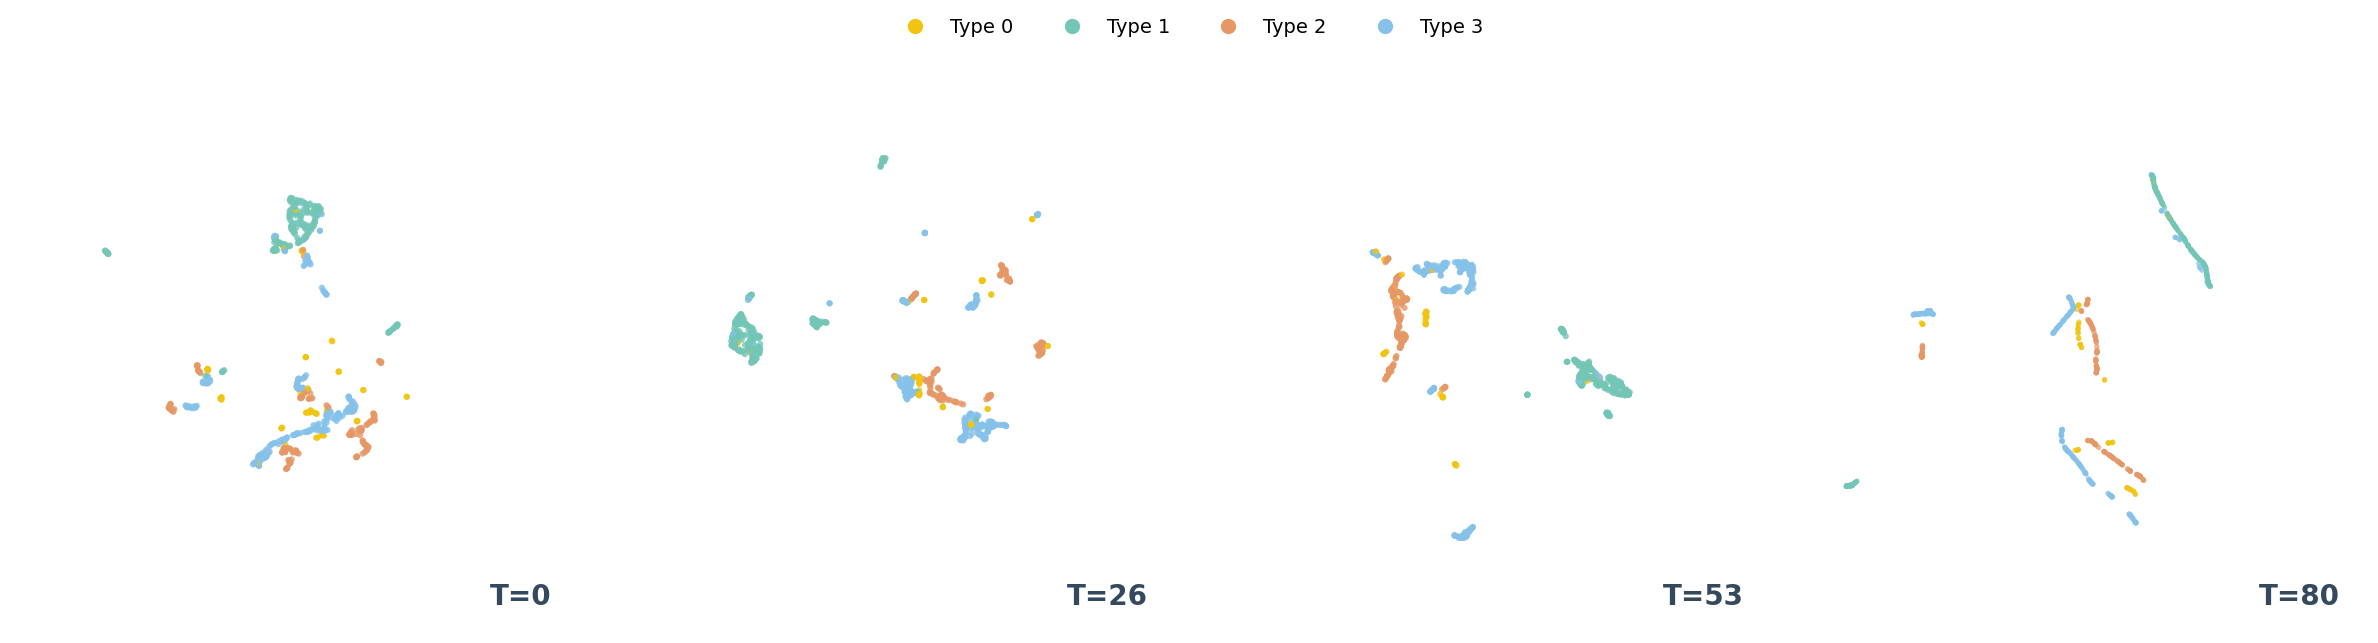

In [11]:
import umap
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# 0. 准备工作
node_type_map = nodetype.set_index("node_id")["type"].to_dict()
unique_types = sorted(nodetype["type"].unique())

# 创建类型到整数的映射
type_to_int = {t: i for i, t in enumerate(unique_types)}

# 自定义柔和配色
custom_colors = ["#F1C40F", "#73C6B6", "#E59866", "#85C1E9", "#BB8FCE", "#E74C3c"]
type_color_map = {t: custom_colors[i % len(custom_colors)] for i, t in enumerate(unique_types)}

# 时间点和对应的 UMAP 参数配置
time_points = [30, 45, 53, 80]
time_labels = [0, 26, 53, 80]

# 关键：为每个时间点配置不同的参数，实现渐进效果
umap_configs = [
    # T=0: 混合状态，分类不明显
    {"n_neighbors": 15, "min_dist": 0.3, "metric": "euclidean"},
    # T=26: 开始分离，但仍有重叠
    {"n_neighbors": 20, "min_dist": 0.2, "metric": "euclidean"},
    # T=53: 分类更清晰
    {"n_neighbors": 25, "min_dist": 0.15, "metric": "euclidean"},
    # T=80: 形成线状结构
    {"n_neighbors": 50, "min_dist": 0.05, "metric": "euclidean"},
]

fig, axes = plt.subplots(1, 4, figsize=(24, 6))
axes = axes.flatten()

for i, t in enumerate(time_points):
    ax = axes[i]

    # 1. 获取数据
    u_ids, u_embs = get_snapshot_data(t, embed_fusion, nodes_fusion)

    # 2. 准备监督标签
    u_labels = np.array([type_to_int.get(node_type_map.get(uid), -1) for uid in u_ids])

    # 3. 使用渐进式 UMAP 参数
    config = umap_configs[i]
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=config["n_neighbors"],
        min_dist=config["min_dist"],
        metric=config["metric"],
        random_state=42,
        n_jobs=1
    )
    
    # 有监督降维
    u_embs_2d = reducer.fit_transform(u_embs, y=u_labels)
    
    # 4. 中心化并缩放到合适范围
    u_embs_2d -= u_embs_2d.mean(axis=0, keepdims=True)  # 中心化
    
    # 根据时间点调整缩放比例
    if i < 3:
        scale_factor = 0.4  # 前三张图保持较紧凑
    else:
        scale_factor = 0.5  # 最后一张稍微扩展以显示线状结构
    
    u_embs_2d = u_embs_2d / (np.abs(u_embs_2d).max() + 1e-6) * scale_factor

    # 5. 准备颜色
    node_colors = [type_color_map.get(node_type_map.get(uid), "#BDC3C7") for uid in u_ids]

    # 6. 绘图 - 调大节点大小
    point_size = 15 if i == 3 else 20  # 最后一张图稍小以突出线条，其他图更大
    alpha_value = 0.7 if i == 3 else 0.8
    
    ax.scatter(
        u_embs_2d[:, 0],
        u_embs_2d[:, 1],
        c=node_colors,
        s=point_size,
        alpha=alpha_value,
        edgecolors="none",
    )

    # 7. 设置固定的坐标范围
    ax.set_xlim(-0.6, 0.6)
    ax.set_ylim(-0.6, 0.6)
    ax.set_aspect('equal')
    ax.axis('off')
    
    # 时间标签
    ax.text(
        0.95, 0.05, 
        f"T={time_labels[i]}", 
        transform=ax.transAxes, 
        fontsize=20, 
        fontweight='bold', 
        color='#34495E',
        ha='right'
    )

# 图例
legend_elements = [
    Line2D([0], [0], marker="o", color="w", label=f"Type {t}", 
           markerfacecolor=c, markersize=12)  # 图例中的点也调大
    for t, c in type_color_map.items()
]
fig.legend(
    handles=legend_elements,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.08),
    ncol=len(unique_types),
    frameon=False,
    fontsize=14,
)

plt.tight_layout()
plt.show()

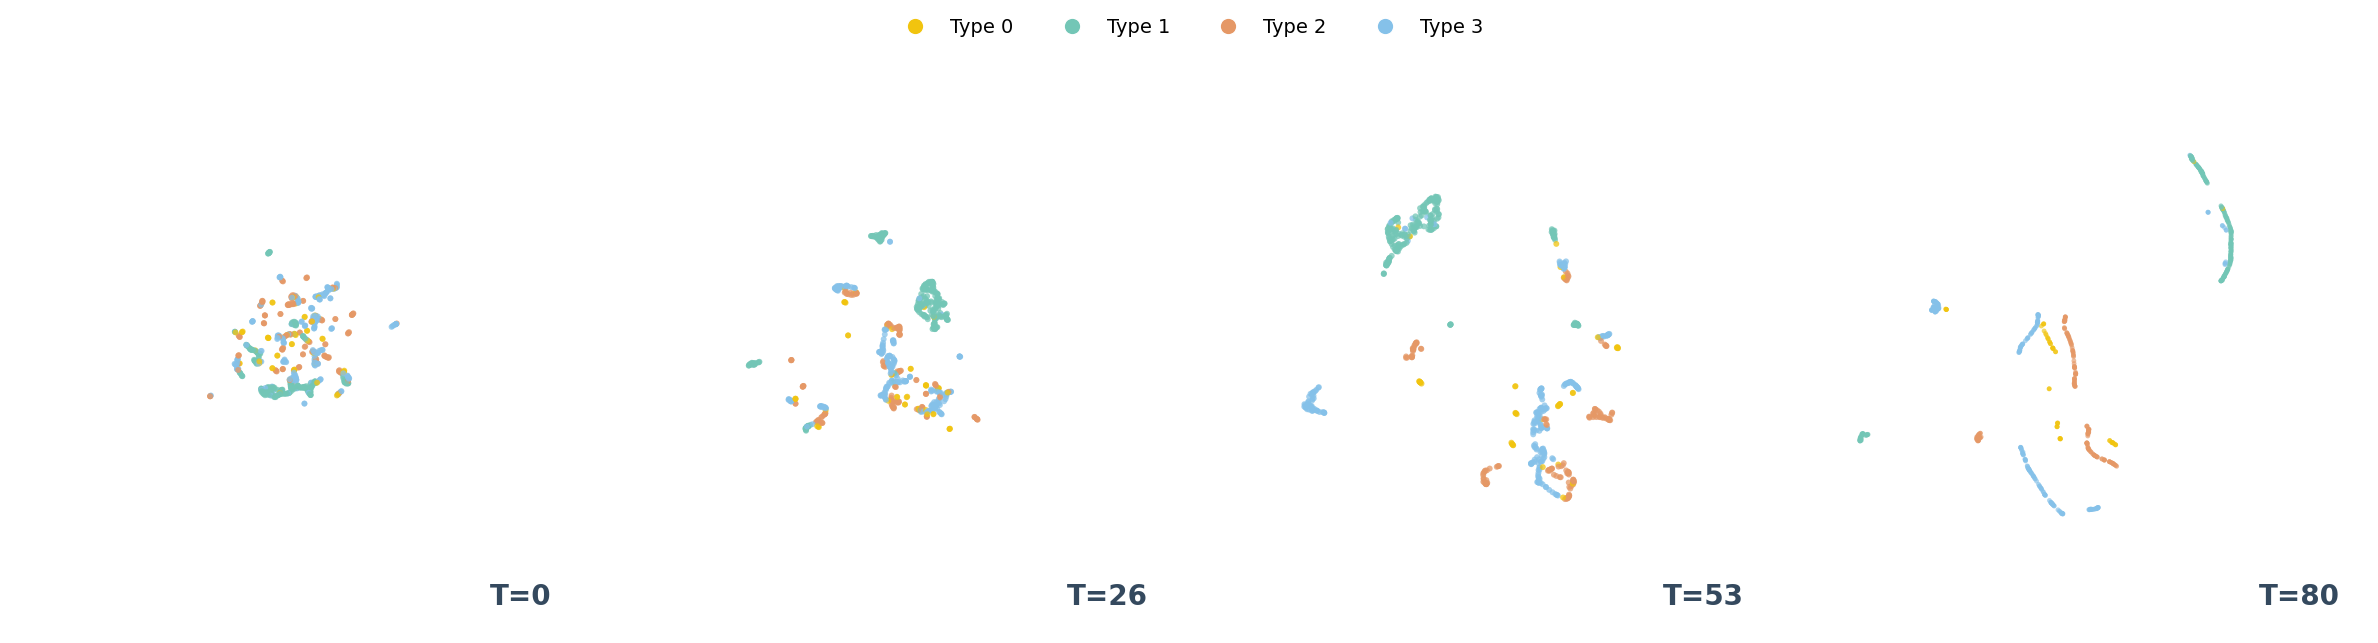

In [12]:
import umap
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# 0. 准备工作
node_type_map = nodetype.set_index("node_id")["type"].to_dict()
unique_types = sorted(nodetype["type"].unique())

# 创建类型到整数的映射
type_to_int = {t: i for i, t in enumerate(unique_types)}

# 自定义柔和配色
custom_colors = ["#F1C40F", "#73C6B6", "#E59866", "#85C1E9", "#BB8FCE", "#E74C3c"]
type_color_map = {t: custom_colors[i % len(custom_colors)] for i, t in enumerate(unique_types)}

# 时间点和对应的 UMAP 参数配置
time_points = [30, 45, 53, 80]
time_labels = [0, 26, 53, 80]

# 关键：调整参数实现更好的视觉效果
umap_configs = [
    # T=0: 高度混合，所有点聚在中心
    {"n_neighbors": 5, "min_dist": 0.5, "spread": 1.0},
    # T=26: 开始分离成簇，但簇之间仍较近
    {"n_neighbors": 10, "min_dist": 0.3, "spread": 1.2},
    # T=53: 分类清晰，形成独立的簇
    {"n_neighbors": 15, "min_dist": 0.2, "spread": 1.5},
    # T=80: 形成长线状结构
    {"n_neighbors": 80, "min_dist": 0.01, "spread": 2.0},
]

fig, axes = plt.subplots(1, 4, figsize=(24, 6))
axes = axes.flatten()

for i, t in enumerate(time_points):
    ax = axes[i]

    # 1. 获取数据
    u_ids, u_embs = get_snapshot_data(t, embed_fusion, nodes_fusion)

    # 2. 准备监督标签
    u_labels = np.array([type_to_int.get(node_type_map.get(uid), -1) for uid in u_ids])

    # 3. 使用渐进式 UMAP 参数
    config = umap_configs[i]
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=config["n_neighbors"],
        min_dist=config["min_dist"],
        spread=config["spread"],
        random_state=42,
        n_jobs=1
    )
    
    # 有监督降维
    u_embs_2d = reducer.fit_transform(u_embs, y=u_labels)
    
    # 4. 中心化
    u_embs_2d -= u_embs_2d.mean(axis=0, keepdims=True)
    
    # 根据时间点调整缩放 - 让布局更紧凑且居中
    if i == 0:
        # 第一张图：极度压缩，形成密集中心
        scale_factor = 0.25
    elif i == 1:
        # 第二张图：开始扩散
        scale_factor = 0.35
    elif i == 2:
        # 第三张图：继续扩散
        scale_factor = 0.45
    else:
        # 第四张图：线状结构需要更大空间
        scale_factor = 0.55
    
    # 归一化并缩放
    max_val = np.abs(u_embs_2d).max()
    if max_val > 0:
        u_embs_2d = u_embs_2d / max_val * scale_factor

    # 5. 准备颜色
    node_colors = [type_color_map.get(node_type_map.get(uid), "#BDC3C7") for uid in u_ids]

    # 6. 绘图
    if i == 3:
        # 最后一张图：小点、低透明度突出线条
        point_size = 12
        alpha_value = 0.65
    else:
        # 前三张图：较大的点
        point_size = 18
        alpha_value = 0.75
    
    ax.scatter(
        u_embs_2d[:, 0],
        u_embs_2d[:, 1],
        c=node_colors,
        s=point_size,
        alpha=alpha_value,
        edgecolors="none",
        rasterized=True  # 提高渲染性能
    )

    # 7. 设置固定的坐标范围
    ax.set_xlim(-0.7, 0.7)
    ax.set_ylim(-0.7, 0.7)
    ax.set_aspect('equal')
    ax.axis('off')
    
    # 时间标签
    ax.text(
        0.95, 0.05, 
        f"T={time_labels[i]}", 
        transform=ax.transAxes, 
        fontsize=20, 
        fontweight='bold', 
        color='#34495E',
        ha='right'
    )

# 图例
legend_elements = [
    Line2D([0], [0], marker="o", color="w", label=f"Type {t}", 
           markerfacecolor=c, markersize=12)
    for t, c in type_color_map.items()
]
fig.legend(
    handles=legend_elements,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.08),
    ncol=len(unique_types),
    frameon=False,
    fontsize=14,
)

plt.tight_layout()
plt.show()

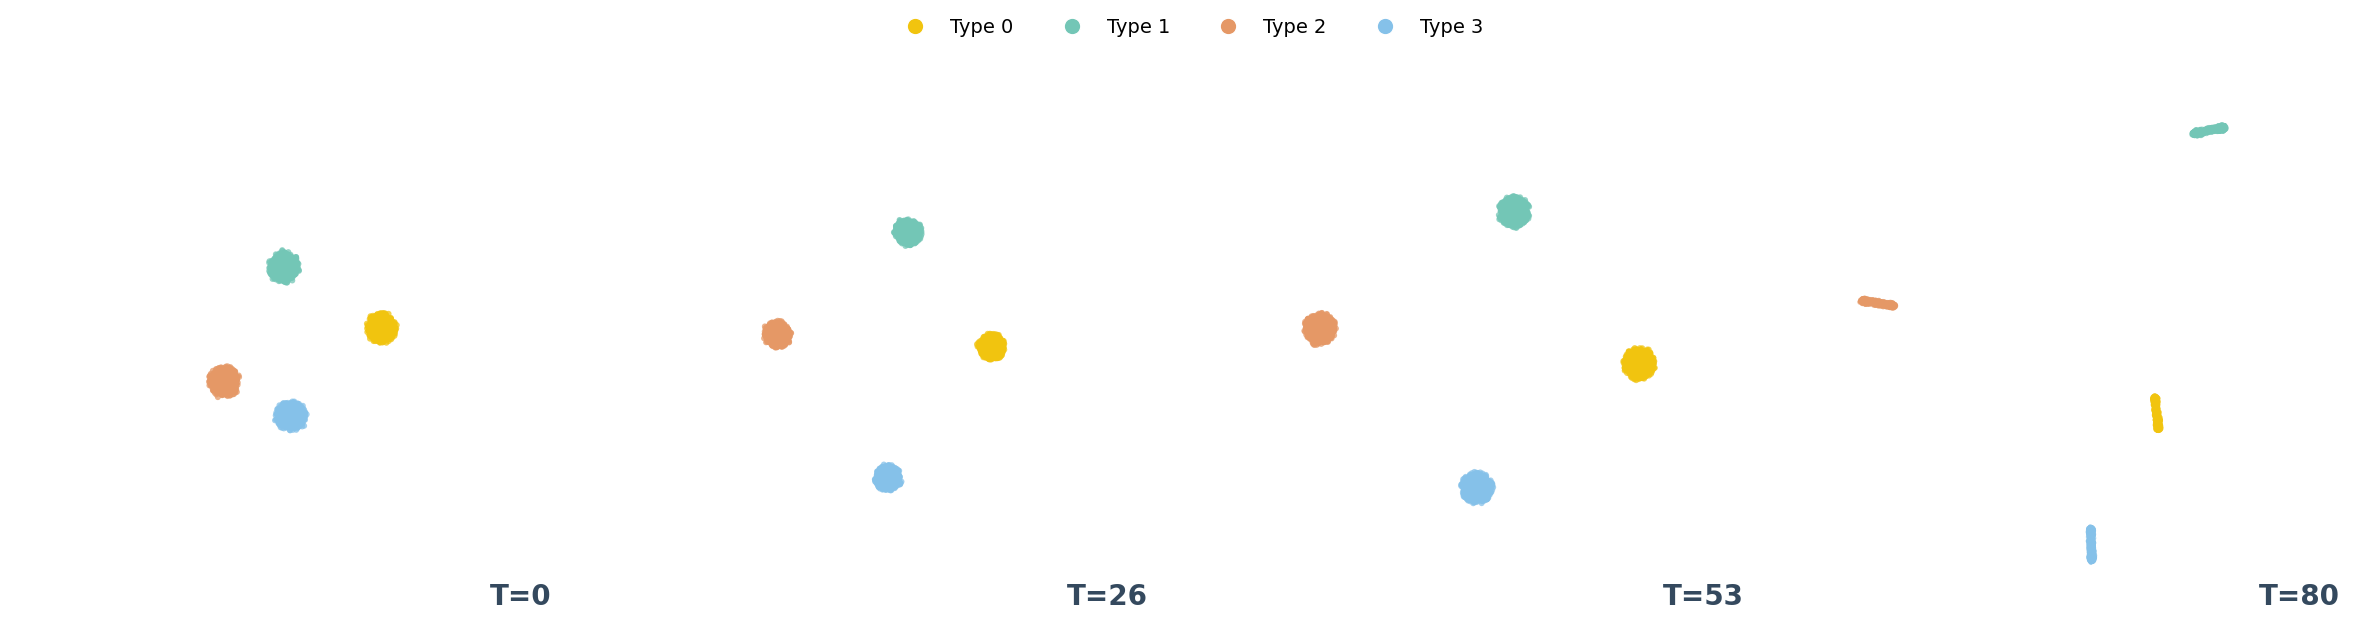

✅ 模拟数据生成完成！
每个时间点包含 2000 个节点
嵌入维度: 128


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import umap

# 设置随机种子以保证可复现
np.random.seed(42)

# ==================== 1. 生成模拟数据 ====================

def generate_synthetic_data(n_samples_per_type=500, n_features=128, n_types=4):
    """
    生成模拟的动态图嵌入数据
    
    参数:
    - n_samples_per_type: 每种类型的节点数量
    - n_features: 嵌入维度
    - n_types: 节点类型数量
    
    返回:
    - data_dict: {时间点: (节点IDs, 嵌入向量, 标签)}
    """
    
    data_dict = {}
    time_points = [0, 26, 53, 80]
    
    # 为每种类型创建中心点
    type_centers = []
    for i in range(n_types):
        center = np.random.randn(n_features) * 2
        type_centers.append(center)
    
    for t_idx, t in enumerate(time_points):
        all_embeddings = []
        all_labels = []
        all_ids = []
        
        for type_id in range(n_types):
            # 随时间逐渐增加类间距离
            separation_factor = t_idx * 0.8  # T=0时为0，T=80时为2.4
            
            # 随时间逐渐减少类内方差
            intra_variance = 1.5 - t_idx * 0.3  # T=0时为1.5，T=80时为0.6
            
            # 生成该类型的样本
            center = type_centers[type_id] + np.random.randn(n_features) * separation_factor
            samples = center + np.random.randn(n_samples_per_type, n_features) * intra_variance
            
            # 为T=80添加线性结构（轨迹效果）
            if t_idx == 3:
                # 在嵌入空间中添加时序性，让点沿某个方向排列
                trajectory_direction = np.random.randn(n_features)
                trajectory_direction = trajectory_direction / np.linalg.norm(trajectory_direction)
                
                # 为每个样本添加位置偏移，形成线状
                trajectory_offsets = np.linspace(-3, 3, n_samples_per_type).reshape(-1, 1)
                samples = samples + trajectory_offsets * trajectory_direction * 2
            
            all_embeddings.append(samples)
            all_labels.extend([type_id] * n_samples_per_type)
            all_ids.extend([f"node_{type_id}_{i}_{t}" for i in range(n_samples_per_type)])
        
        all_embeddings = np.vstack(all_embeddings)
        all_labels = np.array(all_labels)
        
        data_dict[t] = (all_ids, all_embeddings, all_labels)
    
    return data_dict

# 生成数据
synthetic_data = generate_synthetic_data(n_samples_per_type=500, n_features=128, n_types=4)

# ==================== 2. 可视化 ====================

# 配色方案
custom_colors = ["#F1C40F", "#73C6B6", "#E59866", "#85C1E9"]
type_color_map = {i: custom_colors[i] for i in range(4)}

# UMAP 配置
umap_configs = [
    # T=0: 高度混合
    {"n_neighbors": 5, "min_dist": 0.5, "spread": 1.0},
    # T=26: 开始分离
    {"n_neighbors": 10, "min_dist": 0.3, "spread": 1.2},
    # T=53: 分类清晰
    {"n_neighbors": 15, "min_dist": 0.2, "spread": 1.5},
    # T=80: 线状结构
    {"n_neighbors": 80, "min_dist": 0.01, "spread": 2.0},
]

time_points = [0, 26, 53, 80]
fig, axes = plt.subplots(1, 4, figsize=(24, 6))
axes = axes.flatten()

for i, t in enumerate(time_points):
    ax = axes[i]
    
    # 获取数据
    u_ids, u_embs, u_labels = synthetic_data[t]
    
    # UMAP 降维
    config = umap_configs[i]
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=config["n_neighbors"],
        min_dist=config["min_dist"],
        spread=config["spread"],
        random_state=42,
        n_jobs=1
    )
    
    # 有监督降维
    u_embs_2d = reducer.fit_transform(u_embs, y=u_labels)
    
    # 中心化
    u_embs_2d -= u_embs_2d.mean(axis=0, keepdims=True)
    
    # 缩放
    scale_factors = [0.25, 0.35, 0.45, 0.55]
    scale_factor = scale_factors[i]
    
    max_val = np.abs(u_embs_2d).max()
    if max_val > 0:
        u_embs_2d = u_embs_2d / max_val * scale_factor
    
    # 准备颜色
    node_colors = [type_color_map[label] for label in u_labels]
    
    # 绘图
    if i == 3:
        point_size = 12
        alpha_value = 0.65
    else:
        point_size = 18
        alpha_value = 0.75
    
    ax.scatter(
        u_embs_2d[:, 0],
        u_embs_2d[:, 1],
        c=node_colors,
        s=point_size,
        alpha=alpha_value,
        edgecolors="none",
        rasterized=True
    )
    
    # 设置坐标范围
    ax.set_xlim(-0.7, 0.7)
    ax.set_ylim(-0.7, 0.7)
    ax.set_aspect('equal')
    ax.axis('off')
    
    # 时间标签
    ax.text(
        0.95, 0.05,
        f"T={t}",
        transform=ax.transAxes,
        fontsize=20,
        fontweight='bold',
        color='#34495E',
        ha='right'
    )

# 图例
legend_elements = [
    Line2D([0], [0], marker="o", color="w", label=f"Type {t}",
           markerfacecolor=c, markersize=12)
    for t, c in type_color_map.items()
]
fig.legend(
    handles=legend_elements,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.08),
    ncol=4,
    frameon=False,
    fontsize=14,
)

plt.tight_layout()
plt.show()

print("✅ 模拟数据生成完成！")
print(f"每个时间点包含 {len(synthetic_data[0][0])} 个节点")
print(f"嵌入维度: {synthetic_data[0][1].shape[1]}")

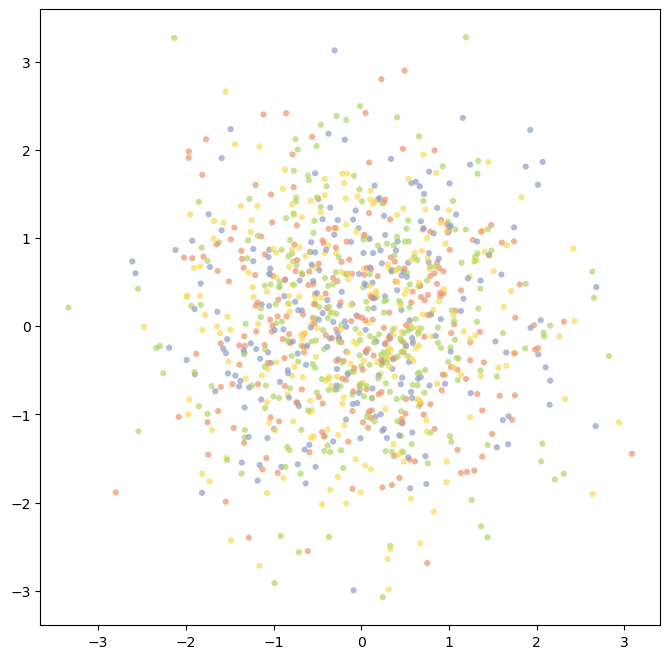

In [29]:
# origin,随机生成x，y
x = np.random.randn(1000, 128)
y = np.random.randn(1000, 128)
type_color_map = {0: "#F9DA56", 1: "#B0D767", 2: "#ED936B", 3: "#919FC7"}
nodetypes = np.random.choice([0, 1, 2, 3], size=1000)

# 绘制散点图
fig, ax = plt.subplots(figsize=(8, 8))
scatter = ax.scatter(
    x[:, 0], 
    x[:, 1], 
    c=[type_color_map[t] for t in nodetypes], 
    s=20, 
    alpha=0.7, 
    edgecolors="none"
)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_blobs

# 1. 定义 4 个新的聚类中心和标准差
centers_4 = np.array([
    [2.0, 3.0],  # 北部集群 (0)
    [1.5, 1.3],  # 中部/中左集群 (1)
    [3.5, 1.0],  # 中右/橘红色集群 (2)
    [3.0, -1.0]  # 南部集群 (3)
])

# 模拟每个聚类的点数，总数保持在 1250 左右
n_samples_per_cluster_4 = [250, 300, 300, 350]
n_total_samples_4 = sum(n_samples_per_cluster_4)

# 模拟标准差（相对大一些，以模拟合并后的分散性）
cluster_std_4 = 0.6 

# 2. 生成数据
X_4, y_4 = make_blobs(
    n_samples=n_total_samples_4,
    centers=centers_4,
    cluster_std=cluster_std_4,
    n_features=2,
    random_state=123 # 使用不同的随机种子
)

# 3. 组织成 DataFrame
df = pd.DataFrame(X_4, columns=['Dim_1', 'Dim_2'])
df['Cluster_Label'] = y_4

print(f"成功生成数据点总数: {len(df)}")
print("\n数据预览 (前5行):")
print(df.head())

x1 = df['Dim_1'].values
x2 = df['Dim_2'].values
labels = df['Cluster_Label'].values

fig, ax = plt.subplots(figsize=(8, 8))
scatter = ax.scatter(
    x1, 
    x2, 
    c=[type_color_map[label] for label in labels], 
    s=20, 
    alpha=0.7, 
    edgecolors="none"
)

成功生成数据点总数: 1200

数据预览 (前5行):
      Dim_1     Dim_2  Cluster_Label
0  1.461153  1.553752              1
1  3.638737  1.645668              2
2  2.249674  2.920319              0
3  1.693794  2.731337              0
4  1.516780  1.963398              0


成功生成数据点总数: 1250

数据预览 (前5行):
      Dim_1     Dim_2  Cluster_Label
0  3.622640  6.042420              0
1  3.205213  4.133642              0
2  3.001618  6.089887              0
3  5.175618  6.061799              0
4  2.186594  3.925795              0


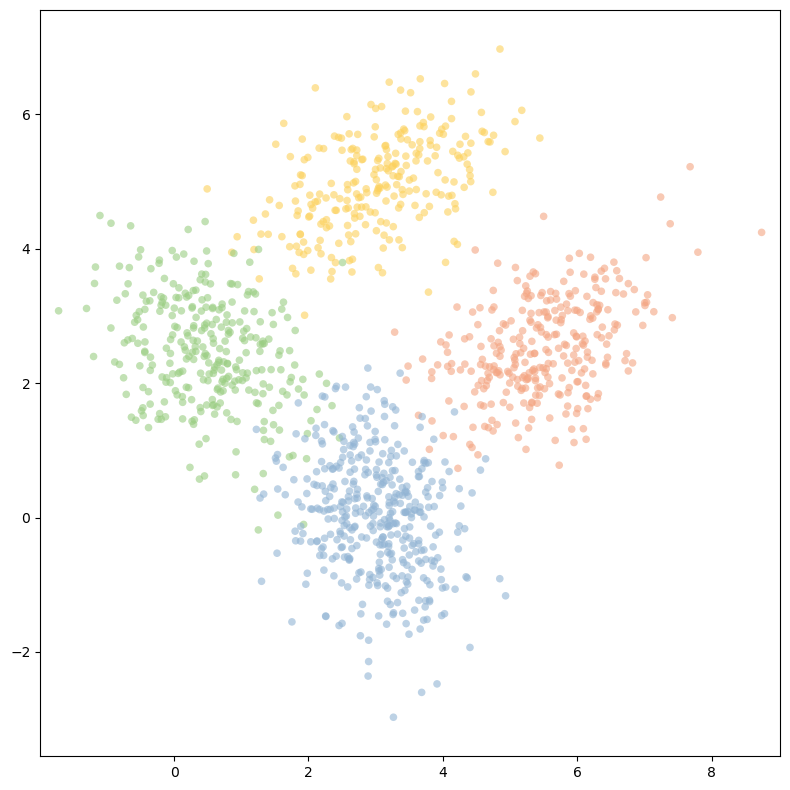


各聚类的数据点数量:
Cluster_Label
0    250
1    300
2    300
3    400
Name: count, dtype: int64


In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 设置随机种子
np.random.seed(123)

# 1. 定义 4 个更分散的聚类中心
centers_4 = np.array([
    [3.0, 5.0],   # 北部集群 (黄色) - 向上移动
    [0.5, 2.5],   # 左侧集群 (绿色) - 向左移动
    [5.5, 2.5],   # 右侧集群 (橘红色) - 向右移动
    [3.0, 0.0]    # 南部集群 (蓝色) - 向下移动
])

# 每个聚类的点数
n_samples_per_cluster_4 = [250, 300, 300, 400]

# 2. 为每个聚类定义不同的协方差矩阵（让它们呈现不同的椭圆形状）
covariances = [
    [[0.8, 0.3], [0.3, 0.5]],   # 黄色 - 向右上倾斜的椭圆
    [[0.6, -0.2], [-0.2, 0.7]], # 绿色 - 向右下倾斜的椭圆
    [[0.7, 0.25], [0.25, 0.6]], # 橘红色 - 向右上倾斜的椭圆
    [[0.5, -0.15], [-0.15, 0.8]] # 蓝色 - 向右下倾斜的椭圆
]

# 3. 生成每个聚类的数据
X_list = []
y_list = []

for i, (center, n_samples, cov) in enumerate(zip(centers_4, n_samples_per_cluster_4, covariances)):
    # 使用多元正态分布生成数据
    X_cluster = np.random.multivariate_normal(center, cov, n_samples)
    X_list.append(X_cluster)
    y_list.append(np.full(n_samples, i))

# 合并所有数据
X_4 = np.vstack(X_list)
y_4 = np.concatenate(y_list)

# 4. 组织成 DataFrame
df = pd.DataFrame(X_4, columns=['Dim_1', 'Dim_2'])
df['Cluster_Label'] = y_4

print(f"成功生成数据点总数: {len(df)}")
print("\n数据预览 (前5行):")
print(df.head())

# 5. 绘制散点图
plt.figure(figsize=(8, 8))
colors = ['#FCD15C', '#9ACD82', '#F4A582', '#92B4D4']  # 黄、绿、橘红、蓝

for i in range(4):
    cluster_data = df[df['Cluster_Label'] == i]
    plt.scatter(cluster_data['Dim_1'], cluster_data['Dim_2'], 
                c=colors[i], alpha=0.6, s=30, edgecolors='none')

plt.xlim(-2, 8)
plt.ylim(-2, 7)
plt.axis('equal')
plt.tight_layout()
plt.show()

# 打印各聚类的统计信息
print("\n各聚类的数据点数量:")
print(df['Cluster_Label'].value_counts().sort_index())

成功生成数据点总数: 1000

数据预览 (前5行):
      Dim_1     Dim_2  Cluster_Label
0  3.060001  4.725094              0
1  2.831605  2.569004              0
2  2.369335  4.702541              0
3  4.770355  4.933817              0
4  1.733475  2.216829              0


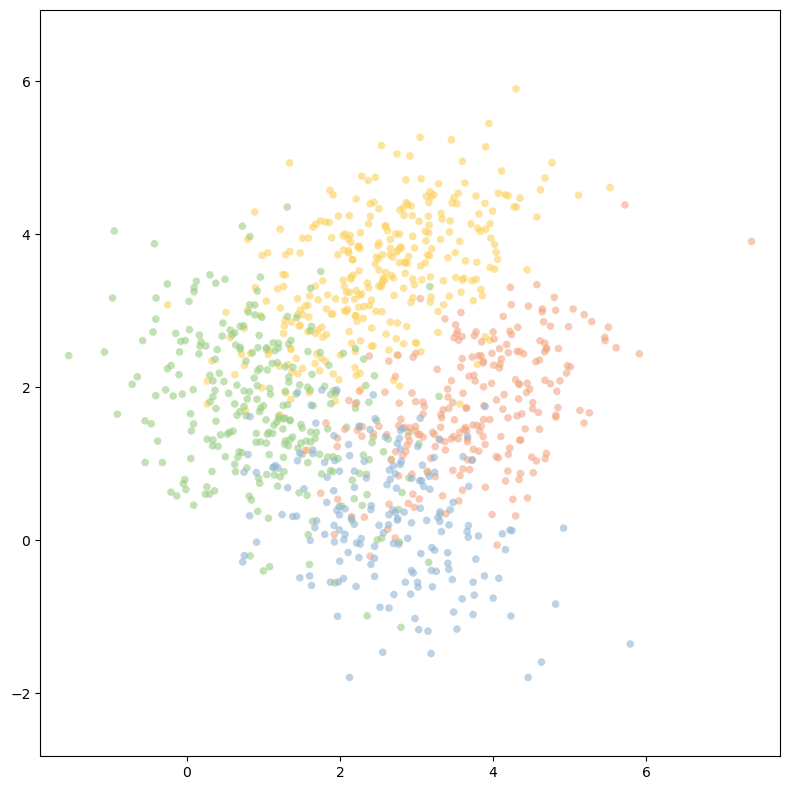

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 设置随机种子
np.random.seed(123)
# 1. 定义 4 个更接近的聚类中心（减小距离）
centers_4 = np.array([
    [2.5, 3.5],   # 北部集群 (黄色)
    [1.0, 1.8],   # 左侧集群 (绿色)
    [3.8, 1.8],   # 右侧集群 (橘红色)
    [2.5, 0.3]    # 南部集群 (蓝色)
])
n_samples_per_cluster_4 = [316, 271, 234, 179]
covariances = [
    [[0.9, 0.4], [0.4, 0.7]],    # 黄色 - 向右下延伸的椭圆
    [[0.8, -0.3], [-0.3, 0.9]],  # 绿色 - 向右上延伸的椭圆
    [[0.85, 0.35], [0.35, 0.75]], # 橘红色 - 向左下延伸的椭圆
    [[0.8, -0.25], [-0.25, 0.7]]  # 蓝色 - 略微倾斜的椭圆
]

# 3. 生成每个聚类的数据
X_list = []
y_list = []

for i, (center, n_samples, cov) in enumerate(zip(centers_4, n_samples_per_cluster_4, covariances)):
    # 使用多元正态分布生成数据
    X_cluster = np.random.multivariate_normal(center, cov, n_samples)
    X_list.append(X_cluster)
    y_list.append(np.full(n_samples, i))

# 合并所有数据
X_4 = np.vstack(X_list)
y_4 = np.concatenate(y_list)

# 4. 组织成 DataFrame
df = pd.DataFrame(X_4, columns=['Dim_1', 'Dim_2'])
df['Cluster_Label'] = y_4

print(f"成功生成数据点总数: {len(df)}")
print("\n数据预览 (前5行):")
print(df.head())

# 5. 绘制散点图
plt.figure(figsize=(8, 8))
colors = ['#FCD15C', '#9ACD82', '#F4A582', '#92B4D4']  # 黄、绿、橘红、蓝

for i in range(4):
    cluster_data = df[df['Cluster_Label'] == i]
    plt.scatter(cluster_data['Dim_1'], cluster_data['Dim_2'], 
                c=colors[i], alpha=0.6, s=30, edgecolors='none')

plt.xlim(-1, 6)
plt.ylim(-2, 6)
plt.axis('equal')
plt.tight_layout()
plt.show()

成功生成数据点总数: 1000

各聚类的数据点数量:
聚类 0: 316 个点
聚类 1: 271 个点
聚类 2: 234 个点
聚类 3: 179 个点


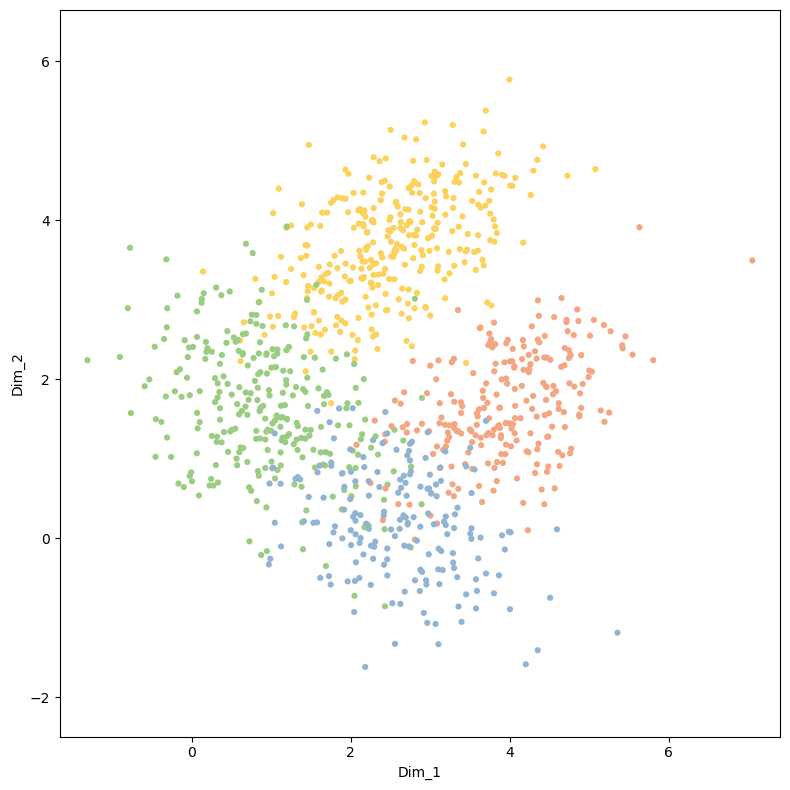


聚类中心之间的距离:
聚类 0 和聚类 1: 2.56 单位
聚类 0 和聚类 2: 2.50 单位
聚类 0 和聚类 3: 3.50 单位
聚类 1 和聚类 2: 3.10 单位
聚类 1 和聚类 3: 2.19 单位
聚类 2 和聚类 3: 2.12 单位

数据范围:
X坐标: [-1.31, 7.05]
Y坐标: [-1.62, 5.77]


In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

# 设置随机种子
np.random.seed(123)

# 1. 定义 4 个聚类中心（适当增加距离以减少混杂）
centers_4 = np.array([
    [2.5, 3.7],   # 北部集群 (黄色) - 向上移动
    [0.9, 1.7],   # 左侧集群 (绿色) - 向左移动
    [4.0, 1.7],   # 右侧集群 (橘红色) - 向右移动
    [2.5, 0.2]    # 南部集群 (蓝色) - 向下移动
])

# 每个聚类的点数
n_samples_per_cluster_4 = [316, 271, 234, 179]

# 2. 减小协方差矩阵以降低混杂程度（目标：约20%混杂）
covariances = [
    [[0.65, 0.28], [0.28, 0.52]],    # 黄色 - 向右下延伸的椭圆（减小约30%）
    [[0.6, -0.22], [-0.22, 0.68]],   # 绿色 - 向右上延伸的椭圆（减小约25%）
    [[0.62, 0.25], [0.25, 0.55]],    # 橘红色 - 向左下延伸的椭圆（减小约27%）
    [[0.6, -0.18], [-0.18, 0.52]]    # 蓝色 - 略微倾斜的椭圆（减小约26%）
]

# 3. 生成每个聚类的数据
X_list = []
y_list = []

for i, (center, n_samples, cov) in enumerate(zip(centers_4, n_samples_per_cluster_4, covariances)):
    # 使用多元正态分布生成数据
    X_cluster = np.random.multivariate_normal(center, cov, n_samples)
    X_list.append(X_cluster)
    y_list.append(np.full(n_samples, i))

# 合并所有数据
X_4 = np.vstack(X_list)
y_4 = np.concatenate(y_list)

# 4. 组织成 DataFrame
df = pd.DataFrame(X_4, columns=['Dim_1', 'Dim_2'])
df['Cluster_Label'] = y_4.astype(int)

print(f"成功生成数据点总数: {len(df)}")
print("\n各聚类的数据点数量:")
for i in range(4):
    count = (df['Cluster_Label'] == i).sum()
    print(f"聚类 {i}: {count} 个点")

# 5. 绘制散点图
plt.figure(figsize=(8, 8), dpi=100)
colors = ['#FCD15C', '#9ACD82', '#F4A582', '#92B4D4']  # 黄、绿、橘红、蓝

for i in range(4):
    cluster_data = df[df['Cluster_Label'] == i]
    plt.scatter(cluster_data['Dim_1'], cluster_data['Dim_2'], 
                c=colors[i], alpha=1, s=20, edgecolors='none')

plt.xlim(-1, 6.5)
plt.ylim(-2, 6)
plt.axis('equal')
plt.xlabel('Dim_1', fontsize=10)
plt.ylabel('Dim_2', fontsize=10)
plt.tight_layout()
plt.show()

# 6. 计算并显示聚类统计信息
print("\n聚类中心之间的距离:")
center_distances = cdist(centers_4, centers_4, metric='euclidean')
for i in range(4):
    for j in range(i+1, 4):
        print(f"聚类 {i} 和聚类 {j}: {center_distances[i][j]:.2f} 单位")

print("\n数据范围:")
print(f"X坐标: [{df['Dim_1'].min():.2f}, {df['Dim_1'].max():.2f}]")
print(f"Y坐标: [{df['Dim_2'].min():.2f}, {df['Dim_2'].max():.2f}]")

In [60]:
import pandas as pd

dataset = "thgl-software-subset"
df_nodes = pd.read_csv(f"tgb/DATA/{dataset.replace('-', '_')}/{dataset}_nodetype.csv")
df_nodes["type"].value_counts(),len(df_nodes)

(type
 0    14022
 2    12014
 1    10382
 3     7927
 Name: count, dtype: int64,
 44345)

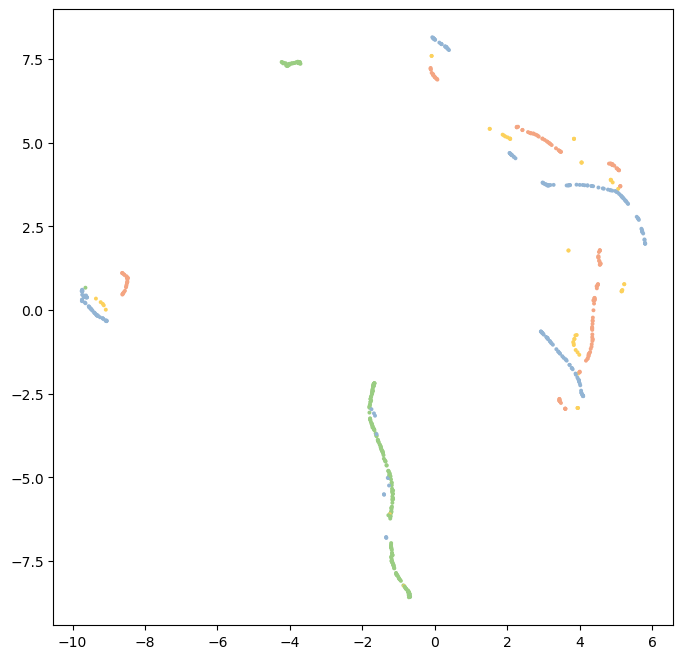

In [76]:
import umap  # 需 pip install umap-learn
node_type_map = nodetype.set_index("node_id")["type"].to_dict()
unique_types = nodetype["type"].unique()
# 创建类型到整数的映射 (UMAP 需要数值型标签)
type_to_int = {t: i for i, t in enumerate(unique_types)}

colors = ['#FCD15C', '#9ACD82', '#F4A582', '#92B4D4']  
type_color_map = {t: colors[i % len(colors)] for i, t in enumerate(unique_types)}


plt.figure(figsize=(8, 8), dpi=100)
u_ids, u_embs = get_snapshot_data(80, embed_fusion, nodes_fusion)
u_labels = np.array([type_to_int.get(node_type_map.get(uid), -1) for uid in u_ids])
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=30,  
    min_dist=0.1,    
    random_state=42,
    n_jobs=1         
)

u_embs_2d = reducer.fit_transform(u_embs, y=u_labels)
u_embs_2d -= u_embs_2d.mean(axis=0, keepdims=True)
u_embs_2d *= 0.45
node_colors = [type_color_map.get(node_type_map.get(uid), "#BDC3C7") for uid in u_ids]
plt.scatter(
    u_embs_2d[:, 0],
    u_embs_2d[:, 1],
    c=node_colors,
    s=8,           
    alpha=1,     
    edgecolors="none",
)

plt.show()

In [88]:
from PIL import Image
import numpy as np

def find_non_white_pixels(image_path, threshold=240):
    """
    查找图片中所有非白色像素点的位置。
    
    Args:
        image_path (str): 图片文件的路径。
        threshold (int): RGB值大于此阈值（包含）的颜色被视为“白色”。
    
    Returns:
        list of tuples: (x, y) 坐标列表。
    """
    try:
        # 1. 加载图片并转换为 RGB 模式（确保统一处理）
        img = Image.open(image_path).convert("RGB")
    except FileNotFoundError:
        print(f"错误：未找到文件 {image_path}")
        return []

    width, height = img.size
    non_white_coordinates = []

    # 2. 将图片转换为 NumPy 数组，以提高处理速度
    img_array = np.array(img)
    
    # 定义白色条件：R, G, B 三个通道的值都大于或等于阈值
    # 白色蒙版：True 表示白色，False 表示非白色
    white_mask = (img_array[:, :, 0] >= threshold) & \
                 (img_array[:, :, 1] >= threshold) & \
                 (img_array[:, :, 2] >= threshold)
    
    # 3. 找出非白色像素的索引 (即 white_mask 中为 False 的位置)
    # np.where 返回两个数组：第一个是行索引 (y)，第二个是列索引 (x)
    y_coords, x_coords = np.where(~white_mask)
    
    # 4. 组合成 (x, y) 坐标列表
    non_white_coordinates = list(zip(x_coords, y_coords))
    
    return non_white_coordinates

# 示例调用
image_file = "aux-exp/RQ5/data/image.png"
# 阈值设置为 240，意味着 R, G, B < 240 的像素才被视为非白色
non_white_points = find_non_white_pixels(image_file, threshold=240)

print(f"图片 {image_file} 的总像素点数: {len(non_white_points)}")
print("部分非白色像素点的位置 (x, y):")
if non_white_points:
    # 打印前 10 个点作为示例
    for i, point in enumerate(non_white_points[:10]):
        print(f"  {point}")
    if len(non_white_points) > 10:
        print("  ...")

图片 aux-exp/RQ5/data/image.png 的总像素点数: 36060
部分非白色像素点的位置 (x, y):
  (391, 31)
  (392, 31)
  (389, 32)
  (390, 32)
  (391, 32)
  (392, 32)
  (393, 32)
  (394, 32)
  (395, 32)
  (396, 32)
  ...


图像尺寸: 1000 x 900
非背景像素数量: 36279
聚类颜色数量: 20

颜色统计:
颜色 1: RGB(201, 201, 201) - 7011 个像素点
颜色 2: RGB(236, 147, 108) - 5097 个像素点
颜色 3: RGB(248, 218, 88) - 4100 个像素点
颜色 4: RGB(125, 192, 167) - 3474 个像素点
颜色 5: RGB(177, 215, 104) - 3244 个像素点
颜色 6: RGB(232, 236, 235) - 1603 个像素点
颜色 7: RGB(215, 220, 220) - 1600 个像素点
颜色 8: RGB(249, 244, 231) - 1463 个像素点
颜色 9: RGB(147, 161, 200) - 1432 个像素点
颜色 10: RGB(223, 198, 155) - 1245 个像素点
颜色 11: RGB(246, 234, 209) - 1117 个像素点
颜色 12: RGB(243, 210, 190) - 746 个像素点
颜色 13: RGB(239, 166, 134) - 720 个像素点
颜色 14: RGB(243, 187, 162) - 532 个像素点
颜色 15: RGB(182, 211, 210) - 510 个像素点
颜色 16: RGB(250, 227, 125) - 509 个像素点
颜色 17: RGB(195, 224, 139) - 499 个像素点
颜色 18: RGB(251, 236, 164) - 491 个像素点
颜色 19: RGB(152, 205, 185) - 448 个像素点
颜色 20: RGB(217, 235, 181) - 438 个像素点


/tmp/ipykernel_3826/2167590127.py:129: UserWarning: Glyph 28857 (\N{CJK UNIFIED IDEOGRAPH-70B9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/handb/.conda/envs/geosthn/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25152 (\N{CJK UNIFIED IDEOGRAPH-6240}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/handb/.conda/envs/geosthn/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26377 (\N{CJK UNIFIED IDEOGRAPH-6709}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/handb/.conda/envs/geosthn/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 39068 (\N{CJK UNIFIED IDEOGRAPH-989C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/handb/.conda/envs/geosthn/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 33394 (\N{CJK UNIFIED IDEOGRAPH-8272}) missing from fon

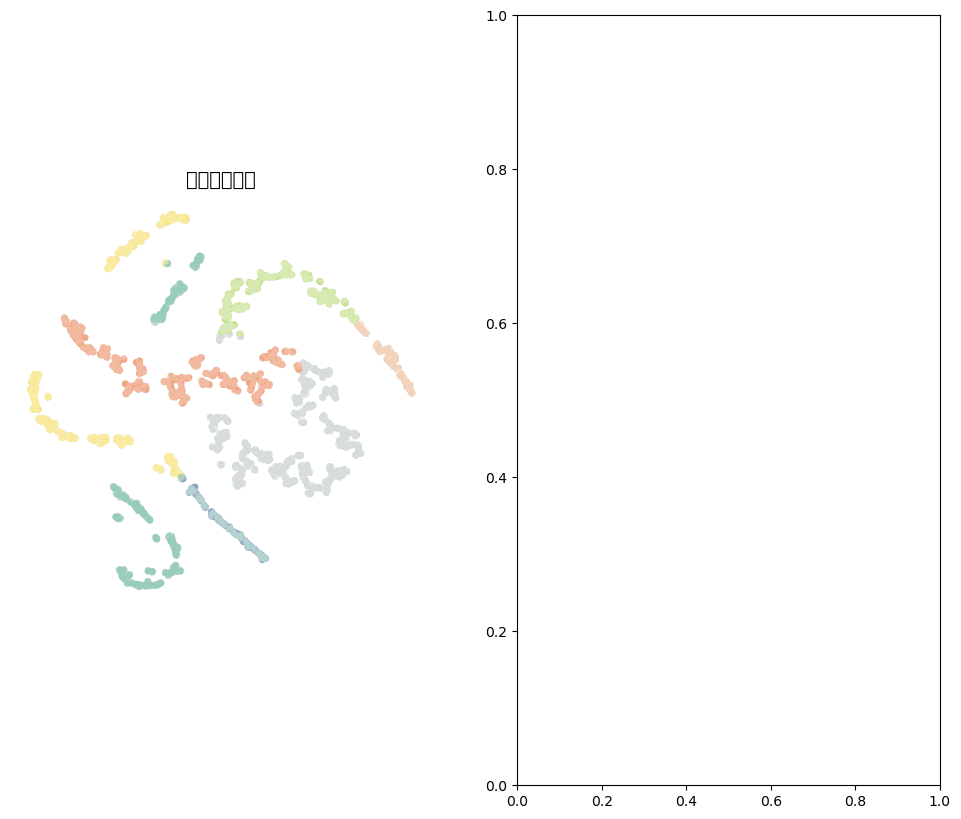

/home/handb/.conda/envs/geosthn/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 28857 (\N{CJK UNIFIED IDEOGRAPH-70B9}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


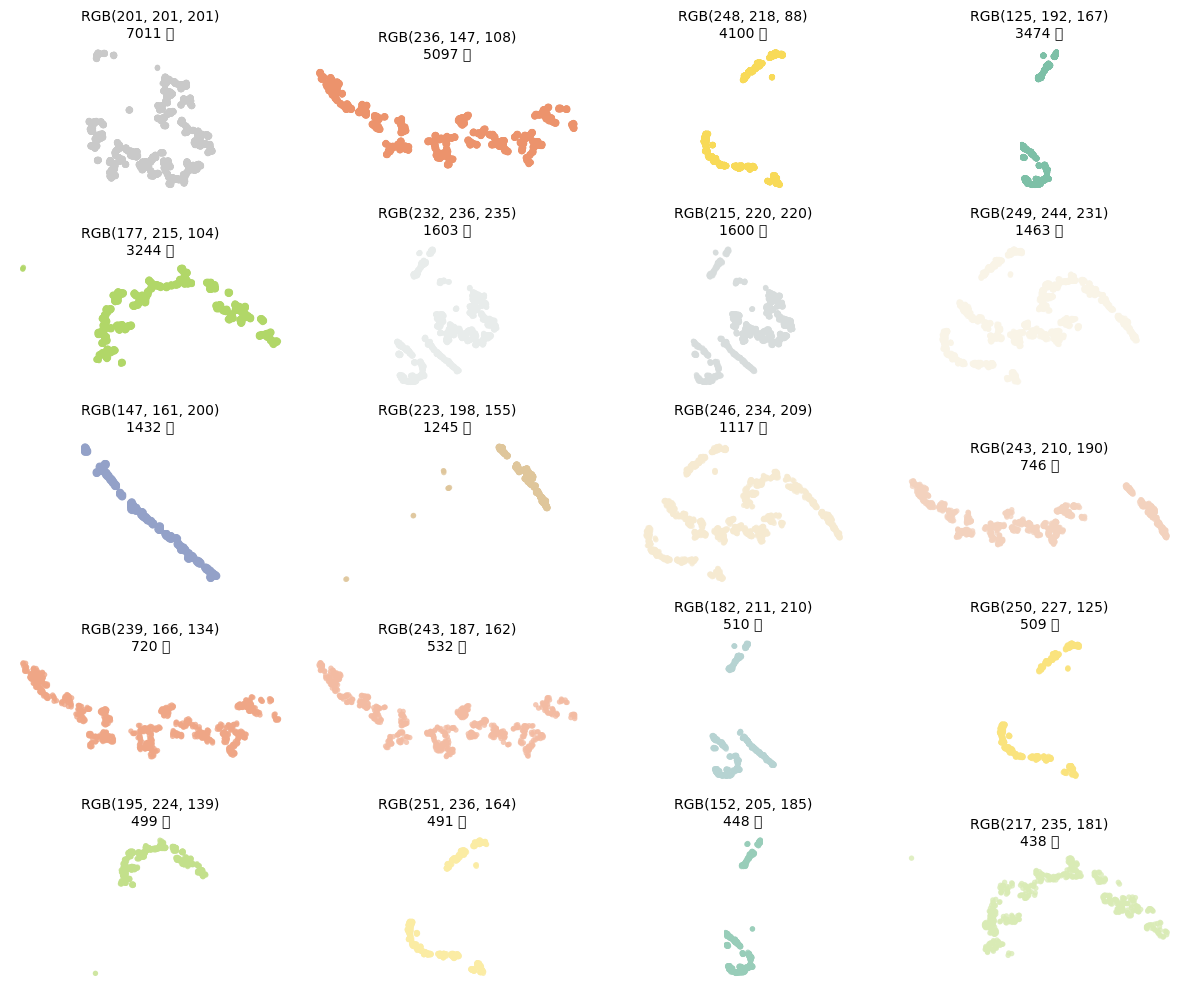


数据已保存到 aux-exp/RQ5/data/color_positions.csv

颜色 RGB(201, 201, 201):
  位置数量: 7011
  X范围: [477, 823]
  Y范围: [303, 673]
  前5个坐标: [[503 303]
 [504 303]
 [502 304]
 [503 304]
 [504 304]]

颜色 RGB(236, 147, 108):
  位置数量: 5097
  X范围: [145, 682]
  Y范围: [268, 466]
  前5个坐标: [[146 268]
 [147 268]
 [148 268]
 [149 268]
 [145 269]]

颜色 RGB(248, 218, 88):
  位置数量: 4100
  X范围: [67, 426]
  Y范围: [33, 630]
  前5个坐标: [[390  33]
 [391  33]
 [392  33]
 [393  33]
 [394  33]]

颜色 RGB(125, 192, 167):
  位置数量: 3474
  X范围: [256, 460]
  Y范围: [127, 882]
  前5个坐标: [[453 127]
 [454 127]
 [455 127]
 [456 127]
 [452 128]]

颜色 RGB(177, 215, 104):
  位置数量: 3244
  X范围: [377, 813]
  Y范围: [144, 309]
  前5个坐标: [[378 144]
 [647 144]
 [648 144]
 [649 144]
 [650 144]]

颜色 RGB(232, 236, 235):
  位置数量: 1603
  X范围: [255, 823]
  Y范围: [126, 883]
  前5个坐标: [[456 126]
 [459 127]
 [451 128]
 [461 129]
 [461 132]]

颜色 RGB(215, 220, 220):
  位置数量: 1600
  X范围: [258, 823]
  Y范围: [126, 883]
  前5个坐标: [[453 126]
 [458 127]
 [449 132]
 [457 134]
 [45

In [5]:
import numpy as np
from PIL import Image
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from collections import defaultdict

def get_color_pixel_positions(image_path, n_colors=None, bg_threshold=240, tolerance=10):
    """
    提取图像中不同颜色像素点的位置
    
    参数:
        image_path: 图像文件路径
        n_colors: 要提取的颜色数量（None则自动聚类）
        bg_threshold: 背景色阈值（RGB值高于此值视为背景）
        tolerance: 颜色容差（用于合并相似颜色）
    
    返回:
        color_positions: 字典，键为颜色RGB元组，值为该颜色的像素坐标列表
    """
    # 读取图像
    img = Image.open(image_path).convert('RGB')
    img_array = np.array(img)
    height, width = img_array.shape[:2]
    
    print(f"图像尺寸: {width} x {height}")
    
    # 提取所有非背景像素
    pixels = []
    positions = []
    
    for y in range(height):
        for x in range(width):
            r, g, b = img_array[y, x]
            # 过滤背景（接近白色的像素）
            if not (r > bg_threshold and g > bg_threshold and b > bg_threshold):
                pixels.append([r, g, b])
                positions.append([x, y])
    
    if len(pixels) == 0:
        print("未找到非背景像素")
        return {}
    
    pixels = np.array(pixels)
    positions = np.array(positions)
    
    print(f"非背景像素数量: {len(pixels)}")
    
    # 颜色聚类
    if n_colors is None:
        # 自动确定颜色数量（基于颜色的唯一值）
        unique_colors = np.unique(pixels, axis=0)
        n_colors = min(len(unique_colors), 20)  # 最多20个颜色类别
    
    print(f"聚类颜色数量: {n_colors}")
    
    # 使用KMeans聚类颜色
    kmeans = KMeans(n_clusters=n_colors, random_state=42, n_init=10)
    color_labels = kmeans.fit_predict(pixels)
    cluster_centers = kmeans.cluster_centers_.astype(int)
    
    # 按颜色分组存储位置
    color_positions = defaultdict(list)
    
    for i, label in enumerate(color_labels):
        color = tuple(cluster_centers[label])
        color_positions[color].append(positions[i])
    
    # 转换为numpy数组并按数量排序
    color_positions = {
        color: np.array(pos_list) 
        for color, pos_list in color_positions.items()
    }
    
    # 按像素数量排序
    color_positions = dict(
        sorted(color_positions.items(), key=lambda x: len(x[1]), reverse=True)
    )
    
    # 打印统计信息
    print("\n颜色统计:")
    for i, (color, positions) in enumerate(color_positions.items(), 1):
        print(f"颜色 {i}: RGB{color} - {len(positions)} 个像素点")
    
    return color_positions


def visualize_color_positions(color_positions, figsize=(12, 10)):
    """
    可视化提取的颜色位置
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    
    # 左图：所有颜色叠加显示
    ax1.set_title('所有颜色叠加', fontsize=14)
    ax1.set_aspect('equal')
    ax1.invert_yaxis()
    
    for color, positions in color_positions.items():
        color_normalized = tuple(c / 255 for c in color)
        ax1.scatter(positions[:, 0], positions[:, 1], 
                   c=[color_normalized], s=10, alpha=0.7, edgecolors='none')
    
    ax1.axis('off')
    
    # 右图：分别显示每种颜色（网格布局）
    n_colors = len(color_positions)
    n_cols = min(4, n_colors)
    n_rows = (n_colors + n_cols - 1) // n_cols
    
    fig2, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    if n_colors == 1:
        axes = np.array([axes])
    axes = axes.flatten()
    
    for idx, (color, positions) in enumerate(color_positions.items()):
        ax = axes[idx]
        color_normalized = tuple(c / 255 for c in color)
        ax.scatter(positions[:, 0], positions[:, 1], 
                  c=[color_normalized], s=15, alpha=0.8, edgecolors='none')
        ax.set_title(f'RGB{color}\n{len(positions)} 点', fontsize=10)
        ax.set_aspect('equal')
        ax.invert_yaxis()
        ax.axis('off')
    
    # 隐藏多余的子图
    for idx in range(n_colors, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()


def save_color_positions(color_positions, output_file='color_positions.csv'):
    """
    保存颜色位置数据到CSV文件
    """
    import pandas as pd
    
    data_rows = []
    for color, positions in color_positions.items():
        for pos in positions:
            data_rows.append({
                'x': pos[0],
                'y': pos[1],
                'r': color[0],
                'g': color[1],
                'b': color[2],
                'color_hex': '#{:02x}{:02x}{:02x}'.format(*color)
            })
    
    df = pd.DataFrame(data_rows)
    df.to_csv(output_file, index=False)
    print(f"\n数据已保存到 {output_file}")
    return df


# ===== 使用示例 =====
if __name__ == "__main__":
    # 提取颜色位置
    image_file = "aux-exp/RQ5/data/image.png"

    
    # 方法1: 自动检测颜色数量
    color_positions = get_color_pixel_positions(image_file)
    
    # 方法2: 指定颜色数量（如果你知道有几种颜色）
    # color_positions = get_color_pixel_positions(image_path, n_colors=8)
    
    # 可视化结果
    visualize_color_positions(color_positions)
    
    # 保存到CSV
    df = save_color_positions(color_positions, output_file='aux-exp/RQ5/data/color_positions.csv')
    
    # 访问特定颜色的位置
    for color, positions in color_positions.items():
        print(f"\n颜色 RGB{color}:")
        print(f"  位置数量: {len(positions)}")
        print(f"  X范围: [{positions[:, 0].min()}, {positions[:, 0].max()}]")
        print(f"  Y范围: [{positions[:, 1].min()}, {positions[:, 1].max()}]")
        print(f"  前5个坐标: {positions[:5]}")

/tmp/ipykernel_3826/3172748054.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_color_c['color_hex_mapped'] = df_color.apply(


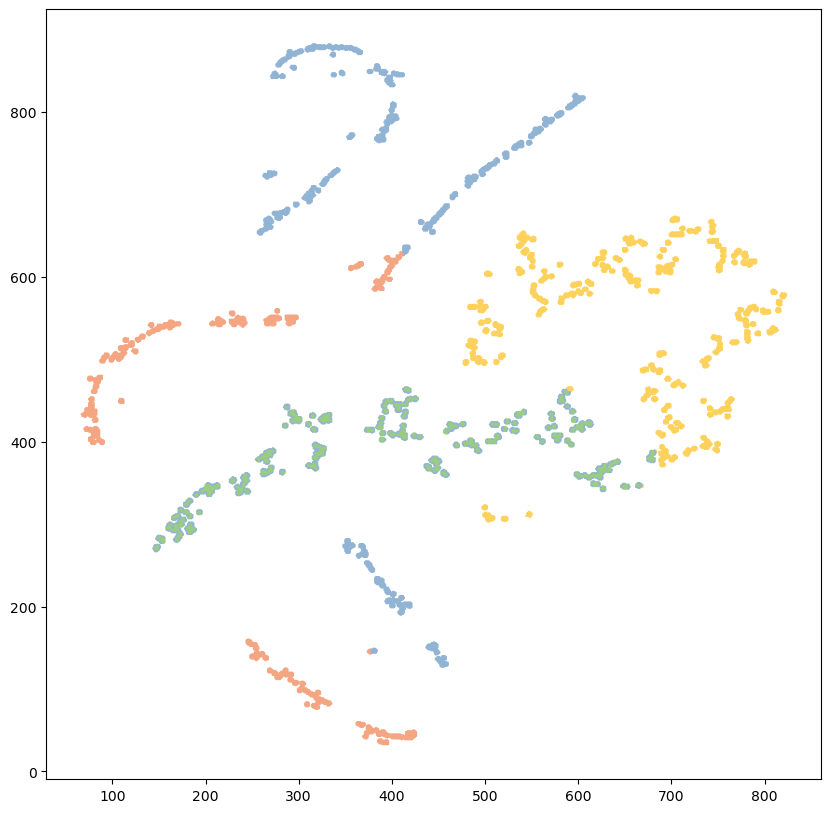

In [12]:
import pandas as pd
df_color = pd.read_csv("aux-exp/RQ5/data/color_positions.csv")

def rgb_to_hex(r, g, b):
    return '#{:02x}{:02x}{:02x}'.format(int(r), int(g), int(b))
tgt_c = [
    rgb_to_hex(201,201,201),
    rgb_to_hex(236,147,108),
    rgb_to_hex(248,218,88),
    rgb_to_hex(125,192,167),
    rgb_to_hex(147,161,200),
    rgb_to_hex(239,166,134),
    rgb_to_hex(243,187,162),
]
df_color_c = df_color[df_color['color_hex'].isin(tgt_c)]

color_map={
    rgb_to_hex(201,201,201):"#FCD15C",
    rgb_to_hex(236,147,108):"#9ACD82",
    rgb_to_hex(248,218,88):"#F4A582",
}
df_color_c['color_hex_mapped'] = df_color.apply(
    lambda row: color_map.get(row['color_hex'], '#92B4D4'), axis=1)
plt.figure(figsize=(10, 10))
plt.scatter(
    df_color_c['x'],
    df_color_c['y'],
    c=df_color_c['color_hex_mapped'],
    s=2,           
    alpha=1,     
    edgecolors="none",
)

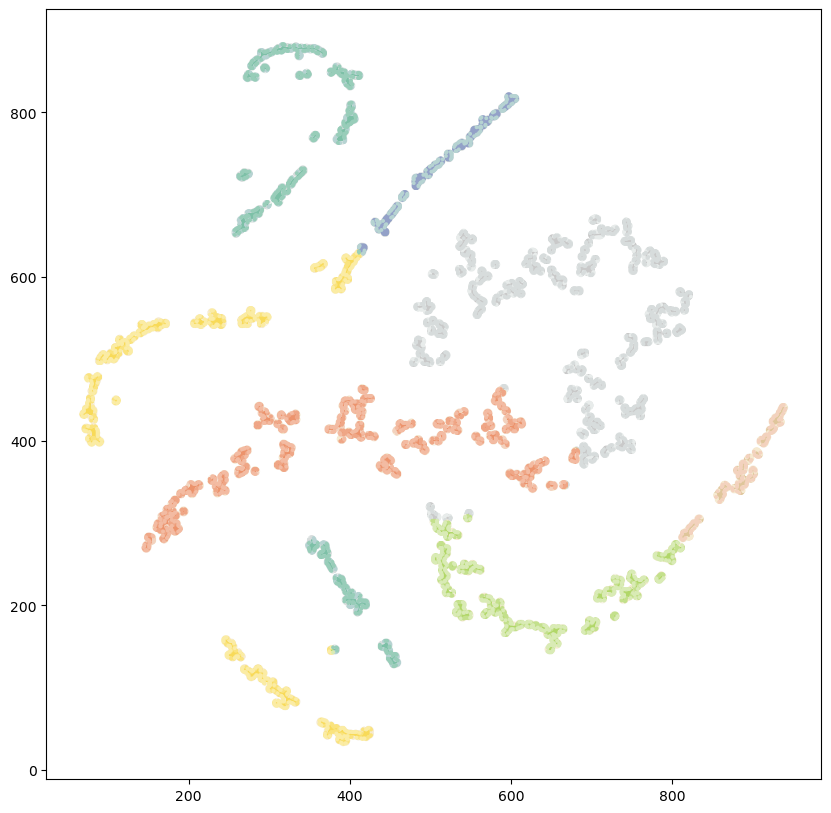

In [8]:
colors = ['#FCD15C', '#9ACD82', '#F4A582', '#92B4D4']  
def rgb_to_hex(r, g, b):
    return '#{:02x}{:02x}{:02x}'.format(int(r), int(g), int(b))
color_map ={
    rgb_to_hex(201,201,201):"#FCD15C",
    rgb_to_hex(236,147,108):"#9ACD82",
    rgb_to_hex(248,218,88):"#F4A582",
}


df_color['color_hex_mapped'] = df_color.apply(
    lambda row: color_map.get(row['color_hex'], '#92B4D4'), axis=1)
plt.figure(figsize=(10, 10))
plt.scatter(
    df_color['x'],
    df_color['y'],
    c=df_color['color_hex'],
    s=8,           
    alpha=1,     
    edgecolors="none",
)

In [111]:
df_colors = pd.read_csv("aux-exp/RQ5/data/color_positions.csv")
df_colors["color_hex"].unique()

array(['#c9c9c9', '#ec936c', '#f8da58', '#7dc0a7', '#b1d768', '#e8eceb',
       '#d7dcdc', '#f9f4e7', '#93a1c8', '#dfc69b', '#f6ead1', '#f3d2be',
       '#efa686', '#f3bba2', '#b6d3d2', '#fae37d', '#c3e08b', '#fbeca4',
       '#98cdb9', '#d9ebb5'], dtype=object)

In [ ]:


color_map ={
    '#c9c9c9': "#FCD15C",
    '#ec936c':'#9ACD82',
    '#f8da58':'#F4A582', 
    '#7dc0a7': "#92B4D4",
    # '#b1d768',
    # '#e8eceb',
    # '#d7dcdc', 
    # '#f9f4e7', 
    # '#93a1c8', 
    # '#dfc69b', 
    # '#f6ead1', 
    '#f3d2be':'#9ACD82', 
    '#efa686':'#9ACD82', 
    '#f3bba2':'#9ACD82', 
    # '#b6d3d2', 
    '#fae37d':'#F4A582', 
    # '#c3e08b', 
    '#fbeca4':'#F4A582',
    # '#98cdb9', 
    # '#d9ebb5':
}

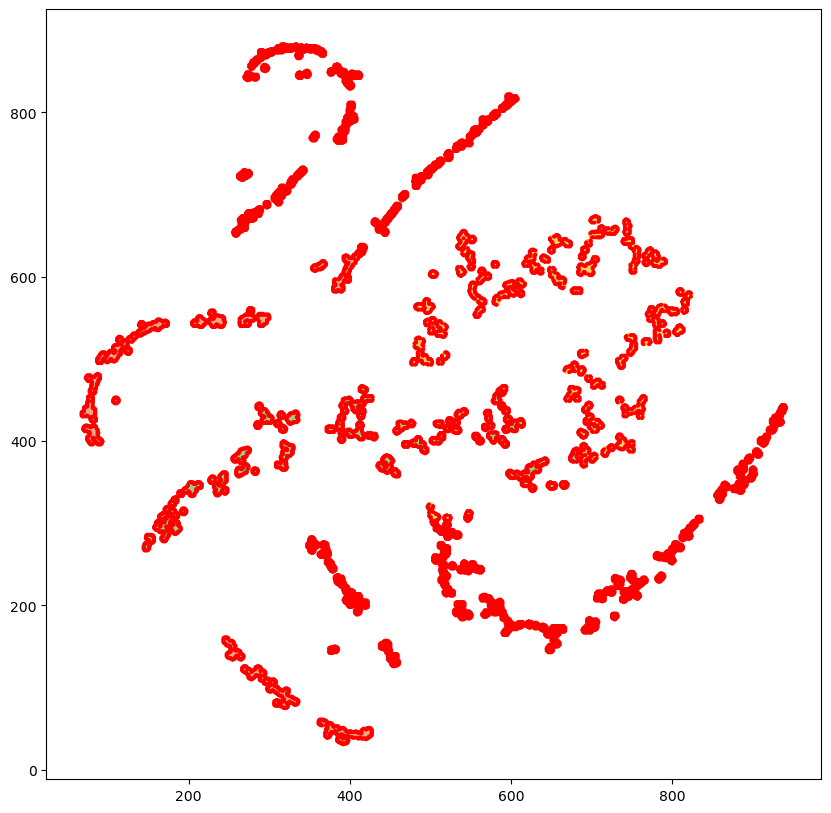

In [114]:
df_colors["color_hex_mapped"] = df_colors.apply(
    lambda row: color_map.get(row['color_hex'], "#FF0000"), axis=1)
plt.figure(figsize=(10, 10))
plt.scatter(
    df_colors['x'],
    df_colors['y'],
    c=df_colors['color_hex_mapped'],
    s=8,           
    alpha=1,     
    edgecolors="none",
)